# Final PCA — Combined Narrative + Supplementary Figures

Structure: the narrative's four numbered sections anchor the notebook, each ending with a
"Supplementary" subsection holding the extra figures that support the
same takeaway (e.g. per-VSM diagnostics under §1, expanded mechanism grids under §2, the
restricted-PCA characterization under §4). All
analysis code runs inline here; figures are written to a new output directory,
`vsm_mech_pca_figures/`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import textwrap

from pathlib import Path
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.optimize import linear_sum_assignment
from scipy.stats import rankdata
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.lines import Line2D
from adjustText import adjust_text

DATA = Path("mech_vsm_gene_corr.tsv")
OUTDIR = Path("vsm_mech_pca_figures")
OUTDIR.mkdir(exist_ok=True)

N_PCS = 5               # PCs kept for every downstream comparison
MATCH_WINDOW = 10       # PCs searched when matching a VSM onto the reference
REFERENCE = "AlphaMissense"  # reference VSM (clean name for AM_score)

PC_NAMES = [f"PC{i}" for i in range(1, N_PCS + 1)]

sns.set_theme(context="notebook", style="white")
plt.rcParams["figure.dpi"] = 110

In [2]:
# surface proteins & protein disorder proportion quartiles
gf = pd.read_csv('../filter_files/ensg_filters.tsv', sep='\t')
gf = gf[['ensg', 'uniprot_id', 'proportion_disordered_q1_low',
         'proportion_disordered_q2', 'proportion_disordered_q3',
         'proportion_disordered_q4_high','surface_protein']]
# raw disorder proportion
dis_df = pd.read_csv('../reference_data/disorder_proportions.tsv', sep='\t')
gf = gf.merge(dis_df, how='left', on='uniprot_id')

In [3]:
# mechanism clean names
mech_names = {'aromatic': 'Aromatic Reference AA', 'charged': 'Charged Reference AA',
              'nonpolar_neutral': 'Nonpolar Reference AA', 'polar_neutral': 'Polar Reference AA',
              'delta_hydropathy': 'Δ Hydropathy', 'delta_molar_mass': 'Δ Molar Mass',
              'SUMOylation': 'SUMOylation', 'acetylation': 'Acetylation', 'glycosylation': 'Glycosylation',
              'methylation': 'Methylation', 'lipidation': 'Lipidation', 'ubiquitination': 'Ubiquitination',
              'phosphorylation': 'Phosphorylation', 'cross_link': 'Cross-link', 'signal': 'Signal',
              'propeptide': 'Propeptide', 'peptide': 'Peptide', 'chain': 'Chain', 'transit_peptide': 'Transit Peptide',
              'all_uniprot_sites': 'Binding/Active Site', 'af2bind_pocket': 'AF2Bind Pocket',
              'domain': 'Domain', 'compositional_bias': 'Compositional Bias', 'region': 'Region',
              'repeat': 'Repeat', 'motif': 'Motif', 'intramembrane': 'Intramembrane', 'transmembrane': 'Transmembrane',
              'topological_domain': 'Topological Domain', 'disulfide_bond': 'Disulfide Bond',
              'intra_chain_hydrogen_bond': 'Intra-chain Hydrogen Bond', 'intra_chain_nonbonded_interaction': 'Intra-chain Nonbonded Interaction',
              'intra_chain_salt_bridge': 'Intra-chain Salt Bridge', 'ss_helix': 'Helix', 'ss_loop_coil': 'Loop/Coil',
              'ss_undefined': 'β-structure', 'β-structure': 'β-structure', 'zinc_finger': 'Zinc Finger', 'druggability_score': 'Druggability Score',
              'foldx_ddg': 'FoldX ΔΔg', 'mobidb_score': 'MobiDB score', 'mu_snp': 'SNP mutation rate',
              'plddt': 'pLDDT', 'rsasa': 'rSASA'}

# VSM clean names
vsm_names = {'AM_score': 'AlphaMissense', 'ESM_1v': 'ESM-1v', 'EVE': 'EVE', 'MisFit_D_score': 'MisFit-D',
             'MisFit_S_score': 'MisFit-S', 'cadd_score': 'CADD', 'cpt_score': 'CPT', 'esm1b': 'ESM-1b',
             'gmvp_score': 'gMVP', 'gpn_msa_score': 'GPN-MSA', 'mcap_score': 'M-CAP', 'mpc_score': 'MPC',
             'phylop': 'PhyloP', 'polyphen_score': 'PolyPhen', 'popEVE': 'popEVE', 'score_PAI3D': 'PAI3D',
             'sift_score': 'SIFT'}


In [4]:
def cosine(a, b):
    """Cosine similarity between two loading vectors (uncentered inner product)."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))


def cosine_matrix(left, right):
    """Pairwise cosine similarity between the columns of two frames."""
    return pd.DataFrame(
        [[cosine(left[i], right[j]) for j in right.columns] for i in left.columns],
        index=left.columns,
        columns=right.columns,
    )


def dendrogram_order(frame, axis=0):
    """Average-linkage leaf order for the rows (axis=0) or columns (axis=1)."""
    data = frame if axis == 0 else frame.T
    labels = frame.index if axis == 0 else frame.columns
    return list(labels[leaves_list(linkage(data.to_numpy(), method="average"))])


In [5]:
raw = pd.read_csv(DATA, sep="\t").set_index(["gene", "vsm"])
# Rename VSMs in the MultiIndex and mechanisms in the columns to clean display names
raw = raw.rename(index=vsm_names, level="vsm")
raw = raw.rename(columns=mech_names)

VSMS = list(raw.index.get_level_values("vsm").unique())
MECHS = list(raw.columns)

print(f"{len(MECHS)} mechanisms (final_pca.ipynb keeps all of them, no >80%-missing filter)")
print(f"{raw.index.get_level_values('gene').nunique():,} genes x {len(VSMS)} VSMs x {len(MECHS)} mechanisms")
print(f"missing cells: {raw.isna().to_numpy().mean():.1%}")

# A missing gene x mechanism correlation means the mechanism never occurs in that
# gene, so 0 ("no association") is the meaningful fill.
mech = raw.fillna(0.0)

43 mechanisms (final_pca.ipynb keeps all of them, no >80%-missing filter)
14,600 genes x 17 VSMs x 43 mechanisms
missing cells: 45.9%


### Input data: average mechanism correlations across VSMs

Before any PCA, the raw gene x mechanism correlations averaged within each VSM (one column per VSM, one row per mechanism) -- the input every PCA below is built from. From `final_pca.ipynb`.

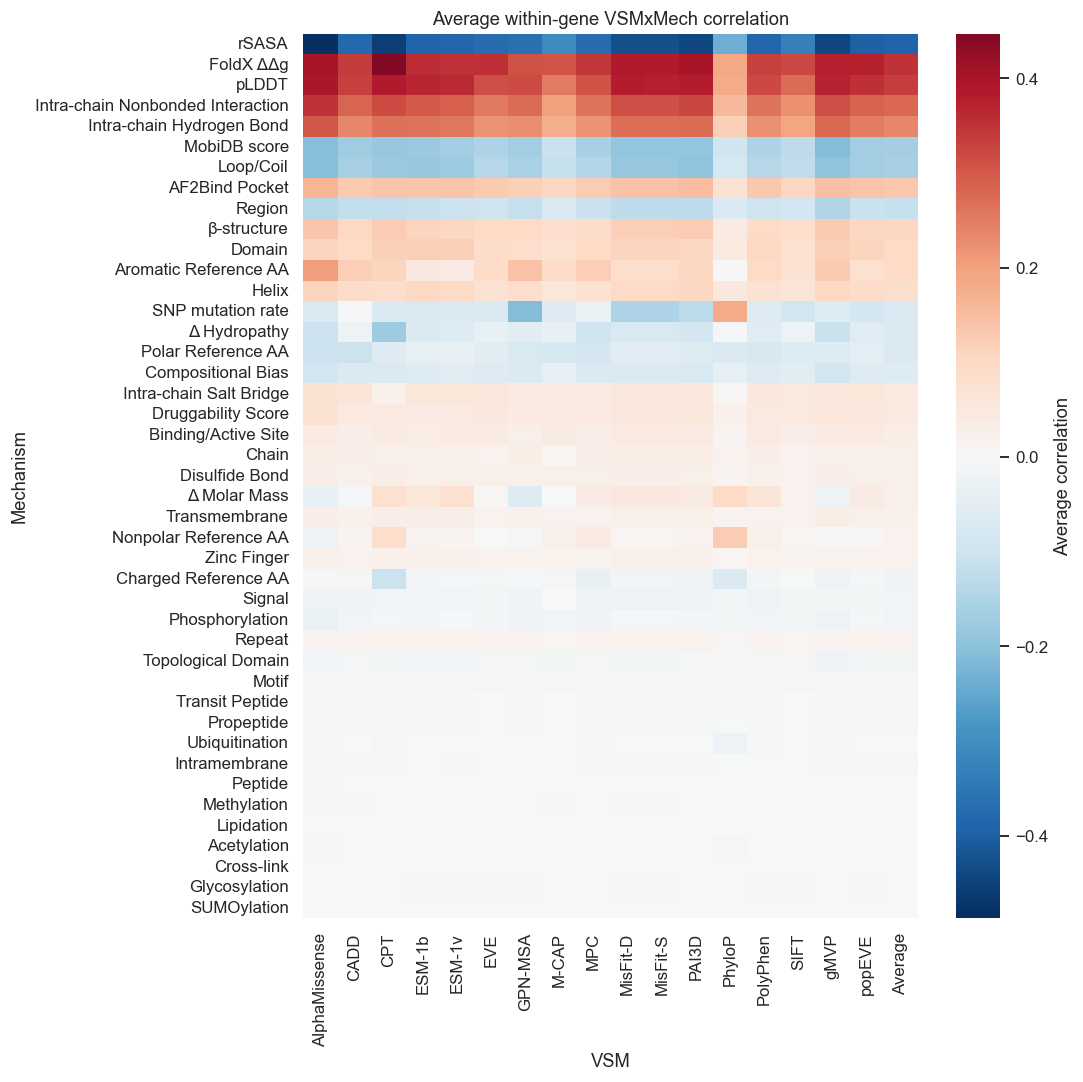

In [6]:
# let's look at the average correlations
mech_avg = mech.groupby(level="vsm").mean().T
# Add average across VSMs
mech_avg["Average"] = mech_avg.mean(axis=1)
# Sort mechanisms by average correlation
#mech_avg = mech_avg.sort_values("Average", ascending=False)
mech_avg = mech_avg.loc[
    mech_avg["Average"].abs().sort_values(ascending=False).index
]

plt.figure(figsize=(10, 10))

ax = sns.heatmap(
    mech_avg,
    cmap="RdBu_r",
    center=0,
    annot=False,
    #fmt=".2f", 
)

ax.collections[0].colorbar.set_label("Average correlation")
plt.xlabel("VSM")
plt.ylabel("Mechanism")
plt.title("Average within-gene VSMxMech correlation")
plt.tight_layout()
#plt.show()

plt.savefig(f'{OUTDIR}/average_correlation.png')

In [7]:
loadings_raw, scores_raw, var_ratio_raw, eigenvalue_raw = {}, {}, {}, {}

for vsm in VSMS:
    X = mech.xs(vsm, level="vsm")
    pca = PCA()
    scores_raw[vsm] = pca.fit_transform(StandardScaler().fit_transform(X))
    names = [f"PC{i + 1}" for i in range(pca.n_components_)]

    loadings_raw[vsm] = pd.DataFrame(pca.components_.T, index=X.columns, columns=names)
    var_ratio_raw[vsm] = pd.Series(pca.explained_variance_ratio_, index=names)
    eigenvalue_raw[vsm] = pd.Series(pca.explained_variance_, index=names)

## 1. Do independent VSMs converge on a shared PCA basis?

Each variant scoring model (VSM) is PCA'd separately over its own per-gene mechanism correlations. A PCA fixes each PC only up to sign and ordering, so nothing forces VSM *A*'s PC3 to describe the same pattern as VSM *B*'s PC3 — each VSM's PCs are matched onto a reference basis (`AlphaMissense`, following `final_pca.ipynb`'s `REFERENCE`) with the Hungarian algorithm on |cosine| similarity, then sign-flipped to agree.


In [8]:
def align_to(reference_loadings, n_pcs=N_PCS, window=MATCH_WINDOW):
    """Match and sign-flip every VSM's PCs onto a reference basis.

    Returns (loadings, scores, var_ratio, eigenvalue, matches), each keyed by VSM.
    `matches[vsm]` records which raw PC supplied each reference slot, its cosine
    to the reference, and whether it was flipped.
    """
    ref = reference_loadings.iloc[:, :n_pcs]
    out_load, out_scores, out_var, out_eig, matches = {}, {}, {}, {}, {}

    for vsm in VSMS:
        cand = loadings_raw[vsm].iloc[:, :window]
        sim = cosine_matrix(ref, cand).to_numpy()
        rows, cols = linear_sum_assignment(-np.abs(sim))

        order = np.empty(n_pcs, dtype=int)
        signs = np.empty(n_pcs, dtype=float)
        for i, j in zip(rows, cols):
            order[i] = j
            signs[i] = np.sign(sim[i, j]) or 1.0

        out_load[vsm] = pd.DataFrame(
            cand.to_numpy()[:, order] * signs, index=cand.index, columns=ref.columns
        )
        out_scores[vsm] = scores_raw[vsm][:, order] * signs
        out_var[vsm] = pd.Series(var_ratio_raw[vsm].to_numpy()[order], index=ref.columns)
        out_eig[vsm] = pd.Series(eigenvalue_raw[vsm].to_numpy()[order], index=ref.columns)
        matches[vsm] = pd.DataFrame(
            {
                "source_pc": cand.columns[order],
                "cosine": sim[np.arange(n_pcs), order],
                "flipped": signs < 0,
            },
            index=ref.columns,
        )

    return out_load, out_scores, out_var, out_eig, matches

loadings, scores, var_ratio, eigenvalue, matches = align_to(loadings_raw[REFERENCE])

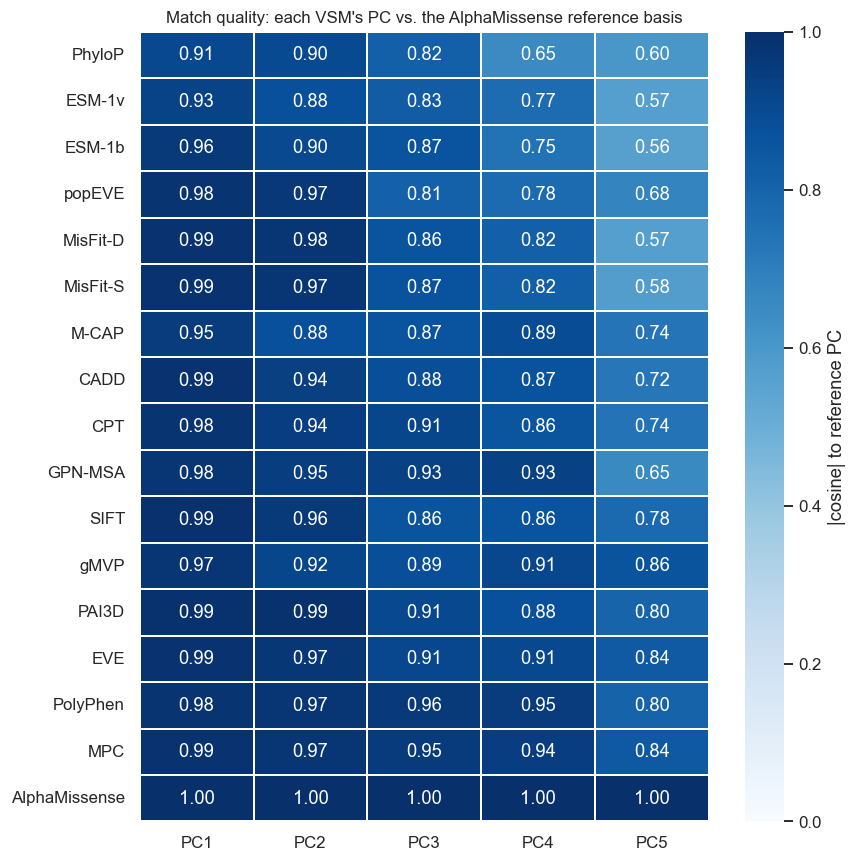

In [9]:
# Fig 1a: match quality -- each VSM's PC vs. the AlphaMissense reference basis
match_quality = pd.DataFrame({vsm: matches[vsm]["cosine"].abs() for vsm in VSMS}).T
match_quality = match_quality.loc[match_quality.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(match_quality, cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".2f",
            linewidths=0.3, ax=ax, cbar_kws={"label": "|cosine| to reference PC"})
ax.set_title(f"Match quality: each VSM's PC vs. the {REFERENCE} reference basis", fontsize=11)
ax.set(xlabel="", ylabel="")
fig.tight_layout()
fig.savefig(OUTDIR / "fig1a_match_cosine_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

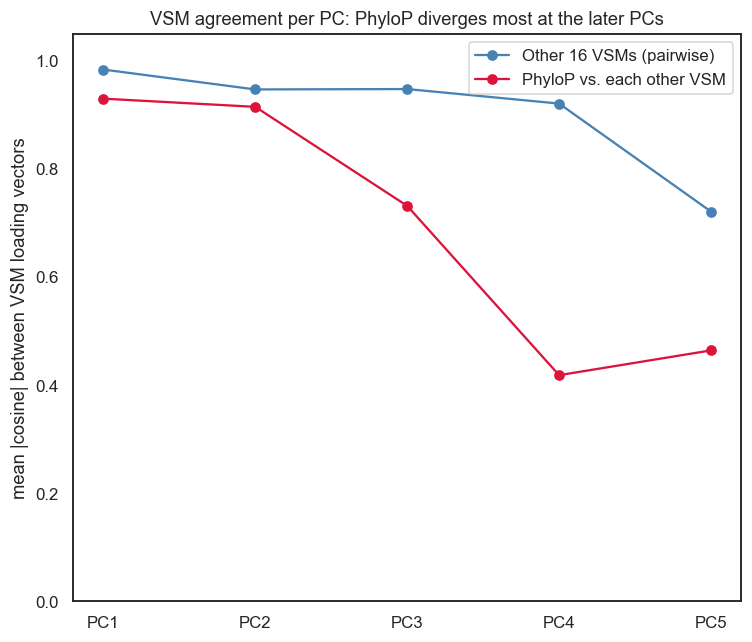

In [10]:
# Fig 1b: does one VSM diverge from the rest more than the rest diverge among themselves?
# (using the aligned, sign-consistent `loadings`)
outlier = match_quality.mean(axis=1).idxmin()
others = [v for v in VSMS if v != outlier]

rest_pairwise, outlier_vs_rest = [], []
for pc in PC_NAMES:
    frame = pd.DataFrame({v: loadings[v][pc] for v in VSMS})
    sim = cosine_matrix(frame, frame).abs()
    rest_vals = sim.loc[others, others].to_numpy()
    iu = np.triu_indices_from(rest_vals, k=1)
    rest_pairwise.append(rest_vals[iu].mean())
    outlier_vs_rest.append(sim.loc[outlier, others].mean())

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(PC_NAMES, rest_pairwise, marker="o", color="steelblue", label=f"Other {len(others)} VSMs (pairwise)")
ax.plot(PC_NAMES, outlier_vs_rest, marker="o", color="crimson", label=f"{outlier} vs. each other VSM")
ax.set(xlabel="", ylabel="mean |cosine| between VSM loading vectors", ylim=(0, 1.05))
ax.set_title(f"VSM agreement per PC: {outlier} diverges most at the later PCs", fontsize=12)
ax.legend()
fig.tight_layout()
fig.savefig(OUTDIR / "fig1b_outlier_vs_rest_agreement.png", dpi=200, bbox_inches="tight")
plt.show()


### Supplementary: consensus loadings and per-VSM agreement

Computes a *consensus* loading vector per PC directly from the aligned per-VSM loadings above (mean loading, renormalised), as an alternative to the gene-level approach used for Fig 2a in §2. The figures below check that consensus, and the per-VSM agreement that produced it, from a few more angles.

In [11]:
def consensus_loadings(aligned):
    """Mean loading vector per PC across VSMs, renormalised to unit length."""
    frame = pd.DataFrame(
        {pc: pd.DataFrame({v: aligned[v][pc] for v in VSMS}).mean(axis=1) for pc in PC_NAMES}
    )
    return frame / np.linalg.norm(frame.to_numpy(), axis=0)


consensus = consensus_loadings(loadings)
#consensus.round(3)

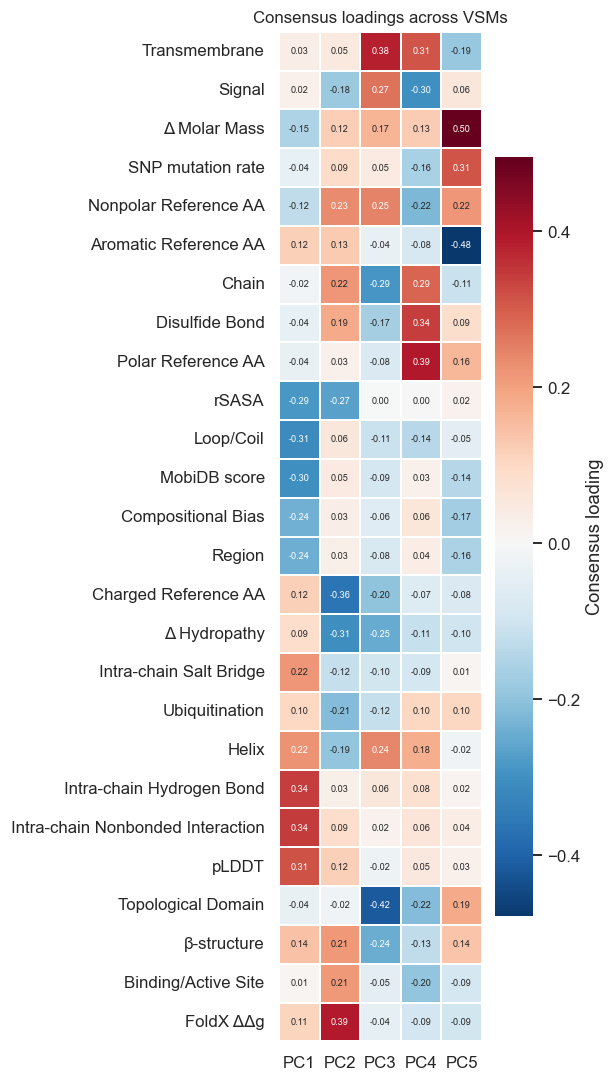

In [12]:
# Consensus loadings: all PCs in one panel, shared scale.
# Minimum absolute loading required for a mechanism to be shown
threshold = 0.21
# Keep mechanisms with at least one PC having |loading| > threshold
keep = consensus.abs().max(axis=1) > threshold
consensus_filtered = consensus.loc[keep]
#print(len(consensus_filtered))
# Get dendrogram order after filtering
ROW_ORDER = dendrogram_order(consensus_filtered, axis=0)

fig, ax = plt.subplots(figsize=(5.5, 10))
sns.heatmap(
    consensus_filtered.loc[ROW_ORDER],
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Consensus loading"},
)

ax.set_title(
    f"Consensus loadings across VSMs",
    fontsize=11,
)
ax.set(xlabel="", ylabel="")

fig.tight_layout()
# fig.savefig(
#     OUTDIR / "consensus_loadings.png",
#     dpi=200,
#     bbox_inches="tight",
# )
plt.show()

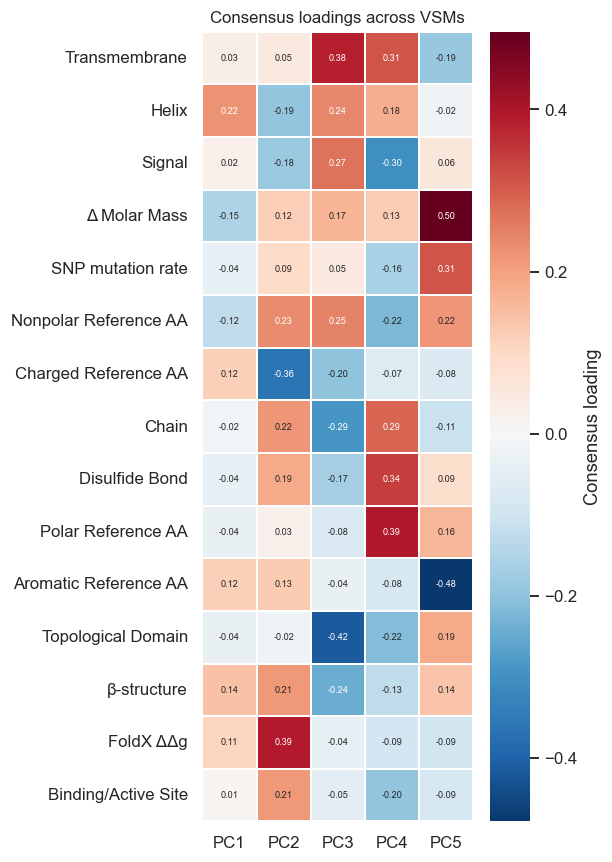

In [13]:
# alternate version of above: keep top rows based on how much they vary across PCs
# Rank mechanisms by variation in their PC loadings
loading_range = consensus.max(axis=1) - consensus.min(axis=1)

# Keep the top 15 most variable mechanisms
top_mechanisms = loading_range.nlargest(15).index
consensus_filtered = consensus.loc[top_mechanisms]

# Get dendrogram order for the filtered mechanisms
ROW_ORDER = dendrogram_order(consensus_filtered, axis=0)

# Apply clean mechanism names for plotting
consensus_plot = consensus_filtered.loc[ROW_ORDER].rename(
    index=mech_names
)

fig, ax = plt.subplots(figsize=(5.5, 8))

sns.heatmap(
    consensus_plot,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 6},
    linewidths=0.3,
    ax=ax,
    cbar_kws={"label": "Consensus loading"},
)

ax.set_title("Consensus loadings across VSMs", fontsize=11)
ax.set(xlabel="", ylabel="")

fig.tight_layout()
# fig.savefig(
#     OUTDIR / "consensus_loadings_top15.png",
#     dpi=200,
#     bbox_inches="tight",
# )
plt.show()

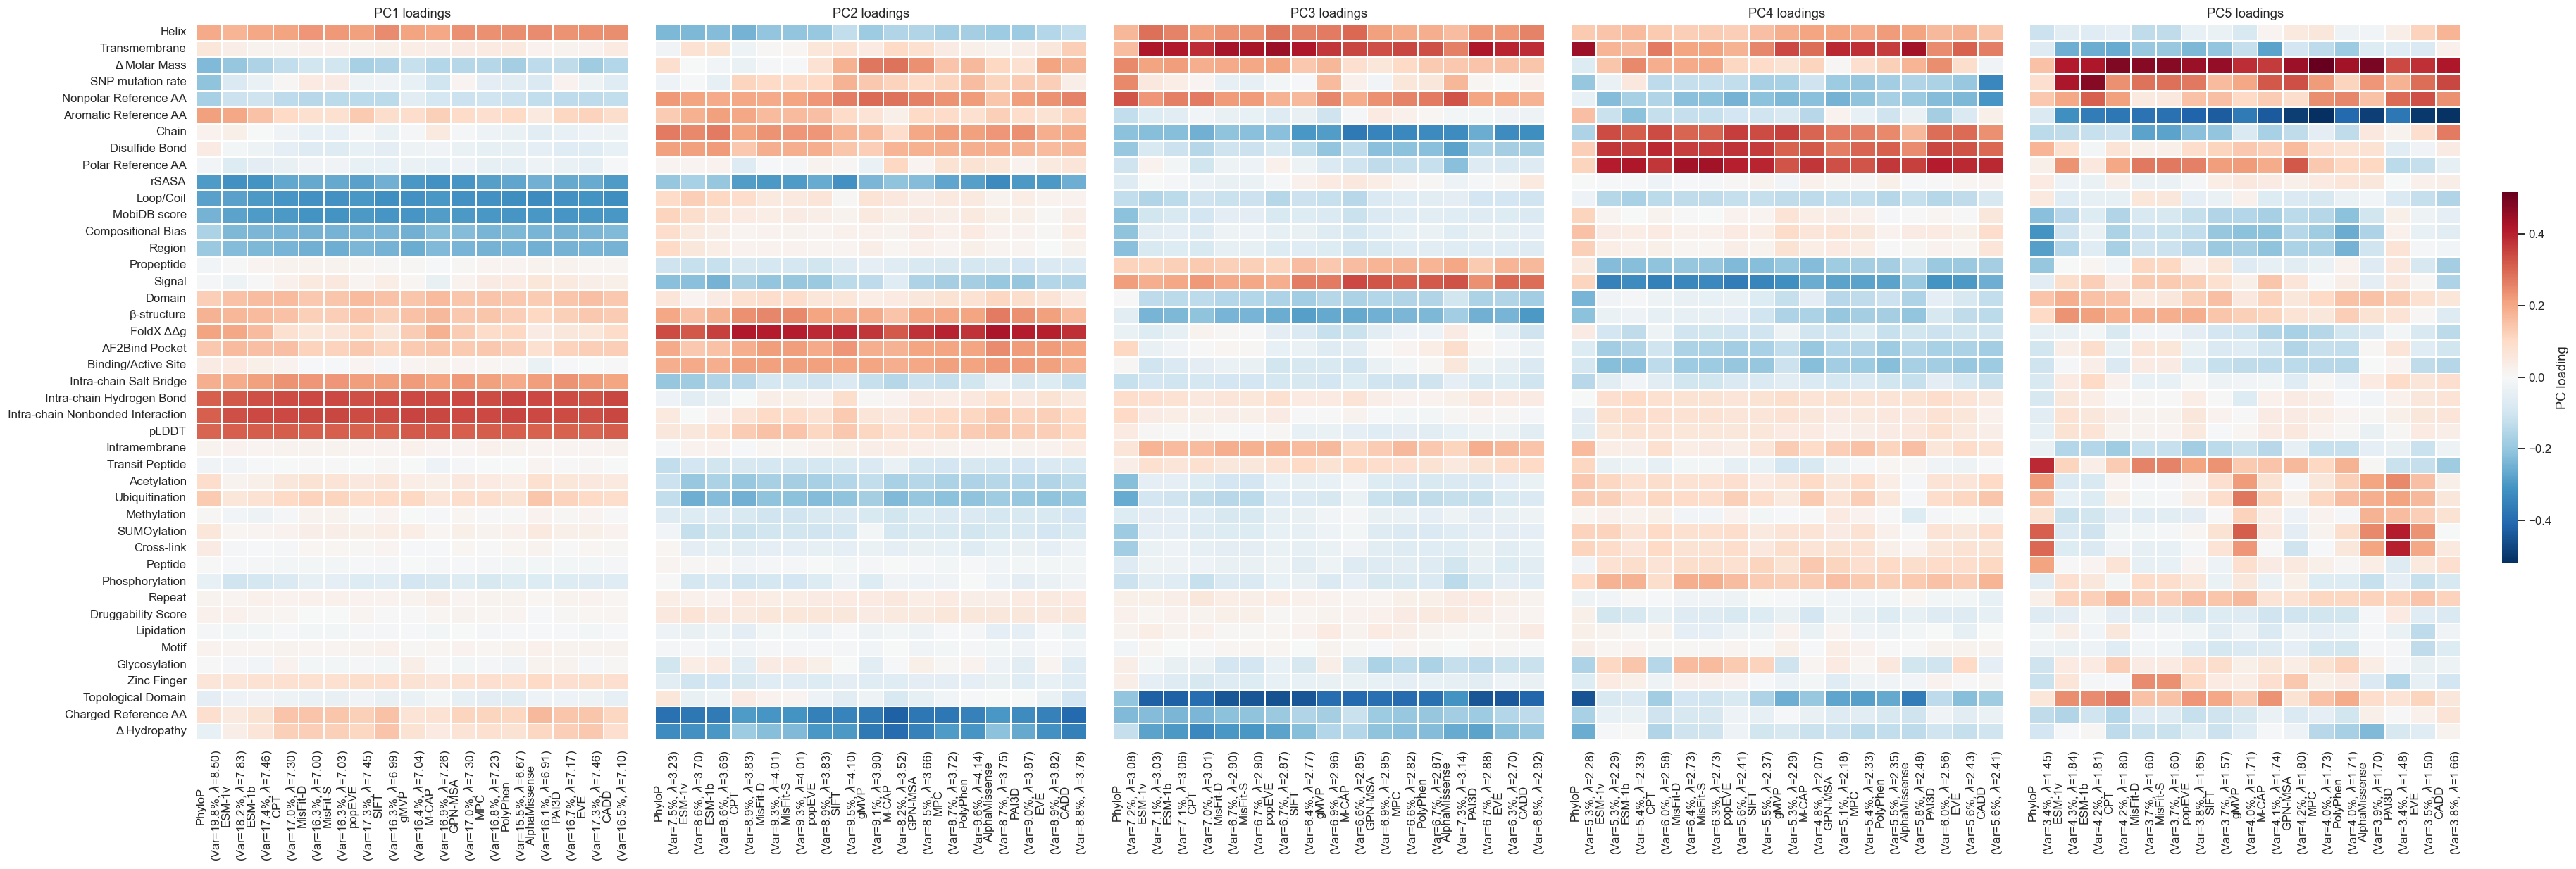

wrote 43 mechanisms to vsm_mech_pc_heatmaps.png


In [14]:
# Heatmaps of loadings: one shared figure, PC1-PC5 side by side (shared y axis, single colorbar)

# Minimum absolute loading required for a mechanism to be shown
LOADING_THRESHOLD = 0.1

# ------------------------------------------------------------------
# Find mechanisms to keep based on loadings across ALL PCs and VSMs
# ------------------------------------------------------------------

# Stack all loadings into one dataframe:
# rows = mechanisms
# columns = VSM × PC combinations
all_loadings = pd.concat(
    {
        v: loadings[v][PC_NAMES]
        for v in VSMS
    },
    axis=1,
)

# Keep a mechanism if it has at least one loading >= threshold
# in absolute value across any PC and any VSM
keep_mechanisms = (
    all_loadings.abs()
    .max(axis=1)
    >= LOADING_THRESHOLD
)

KEEP_ROWS = all_loadings.index[keep_mechanisms]

# ------------------------------------------------------------------
# Determine VSM ordering using the retained mechanisms
# ------------------------------------------------------------------

STACKED = pd.DataFrame(
    {
        v: loadings[v].loc[KEEP_ROWS, PC_NAMES]
        .to_numpy()
        .ravel(order="F")
        for v in VSMS
    }
)

COL_ORDER = dendrogram_order(STACKED, axis=1)

# Shared color scale across all VSMs, PCs, and retained mechanisms
VMAX = max(
    np.abs(loadings[v].loc[KEEP_ROWS, PC_NAMES].to_numpy()).max()
    for v in VSMS
)

ROW_ORDER_F = dendrogram_order(
    all_loadings.loc[KEEP_ROWS],
    axis=0,
)

def plot_pc_loadings(pc, ax, cbar=False, cbar_ax=None):
    """Mechanism x VSM loading heatmap for one PC, using the shared mechanism layout."""
    frame = pd.DataFrame(
        {
            f"{v}\n(Var={var_ratio[v][pc] * 100:.1f}%, "
            f"$\\lambda$={eigenvalue[v][pc]:.2f})":
                loadings[v].loc[KEEP_ROWS, pc]
            for v in COL_ORDER
        }
    )

    # Use the same mechanism ordering for every PC
    frame = frame.loc[[x for x in ROW_ORDER_F if x in frame.index]]

    sns.heatmap(
        frame,
        cmap="RdBu_r",
        center=0,
        vmin=-VMAX,
        vmax=VMAX,
        linewidths=0.2,
        ax=ax,
        cbar=cbar,
        cbar_ax=cbar_ax,
        cbar_kws={"label": "PC loading"} if cbar else None,
    )
    ax.set_title(f"{pc} loadings", fontsize=12)
    ax.set(xlabel="", ylabel="")
    return ax


n_pcs = len(PC_NAMES)
fig, axes = plt.subplots(
    1, n_pcs,
    figsize=(7 * n_pcs, 12),
    sharey=True,
    gridspec_kw={"wspace": 0.06},
)
# single colorbar in its own (unshared) axis to the right of the panels
fig.subplots_adjust(right=0.96)
cbar_ax = fig.add_axes([0.975, 0.3, 0.006, 0.4])
for k, (pc, ax) in enumerate(zip(PC_NAMES, axes)):
    plot_pc_loadings(pc, ax, cbar=(k == 0), cbar_ax=cbar_ax)
    if k > 0:
        ax.tick_params(axis="y", left=False, labelleft=False)

fig.savefig(OUTDIR / "vsm_mech_pc_heatmaps.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"wrote {len(KEEP_ROWS)} mechanisms to vsm_mech_pc_heatmaps.png")


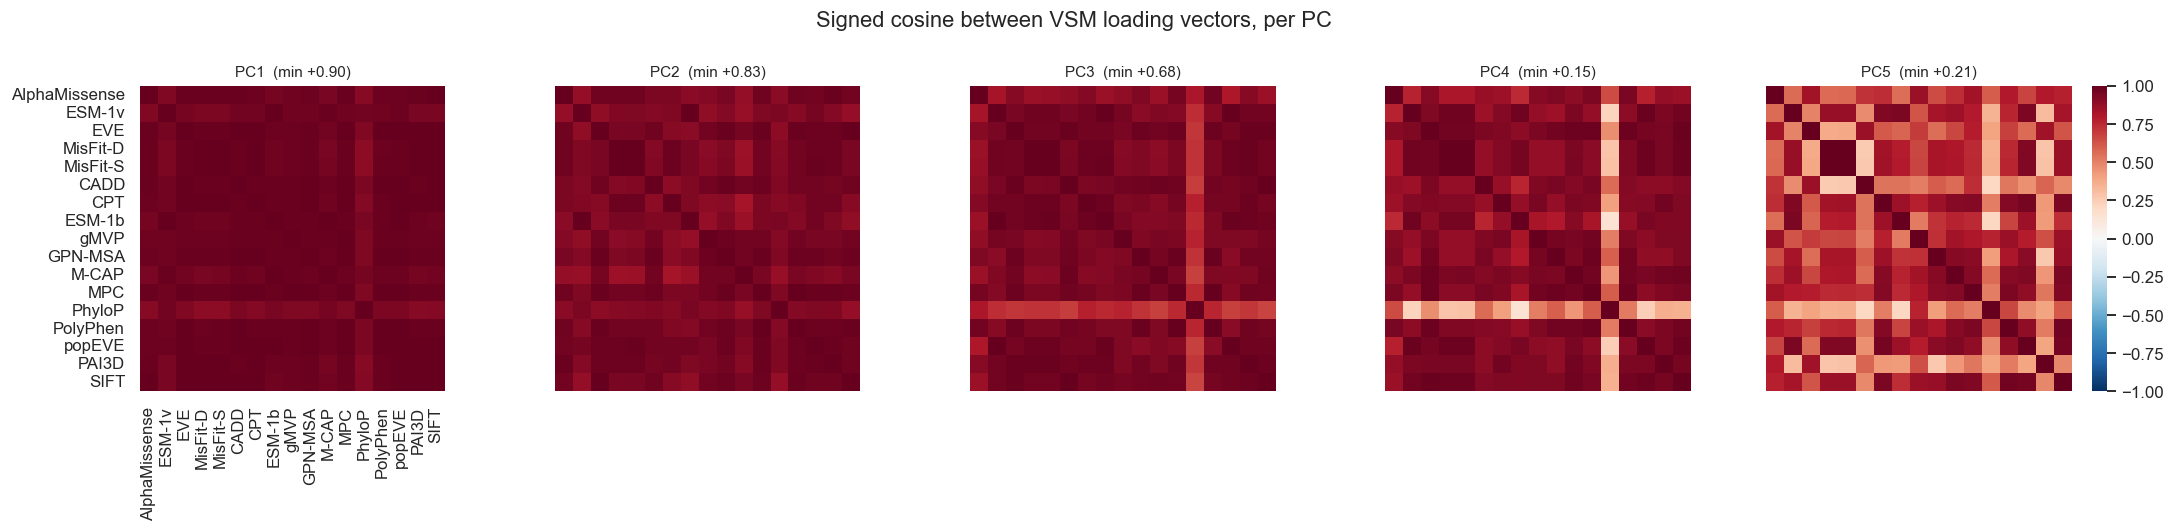

In [15]:
# Pairwise, signed similarity between VSMs within each PC -- one row per PC.
fig, axes = plt.subplots(1, N_PCS, figsize=(4.1 * N_PCS, 4.4))
for ax, pc in zip(np.atleast_1d(axes), PC_NAMES):
    frame = pd.DataFrame({v: loadings[v][pc] for v in VSMS})
    sim = cosine_matrix(frame, frame)
    sns.heatmap(sim, cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True,
                ax=ax, cbar=(pc == PC_NAMES[-1]),
                xticklabels=(pc == PC_NAMES[0]), yticklabels=(pc == PC_NAMES[0]))
    ax.set_title(f"{pc}  (min {sim.to_numpy().min():+.2f})", fontsize=10)

fig.suptitle("Signed cosine between VSM loading vectors, per PC", y=1.02)
fig.tight_layout()
fig.savefig(OUTDIR / "vsm_similarity_per_pc.png", dpi=200, bbox_inches="tight")
plt.show()

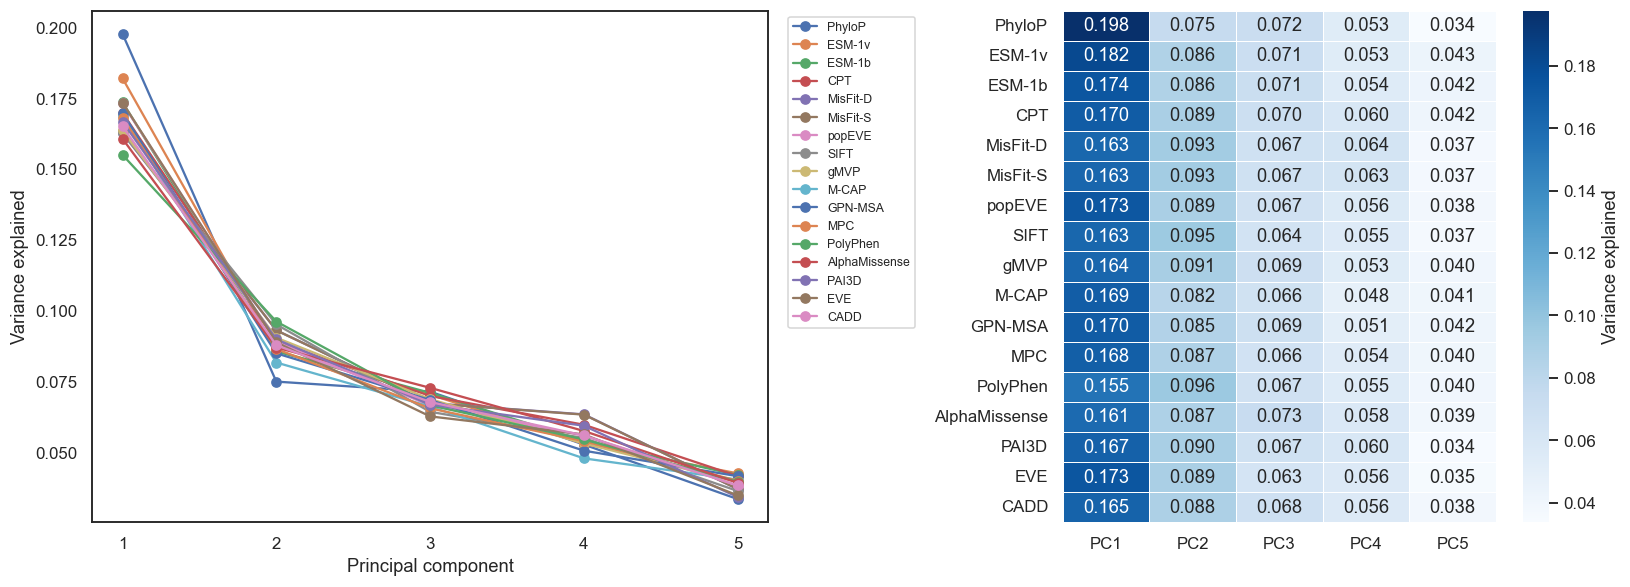

In [16]:
# variance explained
explained_df = pd.DataFrame({vsm: var_ratio[vsm] for vsm in COL_ORDER}).T

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5),
                               gridspec_kw={"width_ratios": [1.25, 1]})

for vsm in explained_df.index:
    ax1.plot(range(1, N_PCS + 1), explained_df.loc[vsm], marker="o", label=vsm)
ax1.set(xlabel="Principal component", ylabel="Variance explained",
        xticks=range(1, N_PCS + 1))
ax1.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

sns.heatmap(explained_df, annot=True, fmt=".3f", cmap="Blues", linewidths=0.4,
            ax=ax2, cbar_kws={"label": "Variance explained"})
ax2.set(xlabel="", ylabel="")

fig.tight_layout()
#fig.savefig(OUTDIR / "variance_explained.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. What do the consensus PCs mean mechanistically?

Switching to a **gene-level** PCA over VSM-averaged mechanism correlations (one PCA over the consensus, not 17 separate ones). `PhyloP` is excluded here — §1 showed it is the clear outlier among VSMs, so it would otherwise distort the "consensus" gene-level signal.


In [17]:
def pca_on(frame):
    """PCA of a (samples x mechanisms) frame; returns (pca, scores, loadings)."""
    filled = frame.fillna(0.0)
    pca = PCA()
    scores_ = pca.fit_transform(StandardScaler().fit_transform(filled))
    loadings_ = pd.DataFrame(
        pca.components_.T,
        index=filled.columns,
        columns=[f"PC{i + 1}" for i in range(pca.n_components_)],
    )
    return pca, scores_, loadings_

mech_wp = mech.drop(index="PhyloP", level="vsm")  # remove PhyloP -- outlier (Fig 1)
gene_avg = mech_wp.groupby(level="gene").mean()

pca_g, scores_g, loadings_g = pca_on(gene_avg)

print(f"gene-level: {gene_avg.shape[0]:,} genes, PC1 = {pca_g.explained_variance_ratio_[0]:.1%}")
for i in range(N_PCS):
    print(f"  PC{i+1}: {pca_g.explained_variance_ratio_[i]:.1%} of variance")


gene-level: 14,600 genes, PC1 = 16.8%
  PC1: 16.8% of variance
  PC2: 9.4% of variance
  PC3: 6.8% of variance
  PC4: 5.9% of variance
  PC5: 3.8% of variance


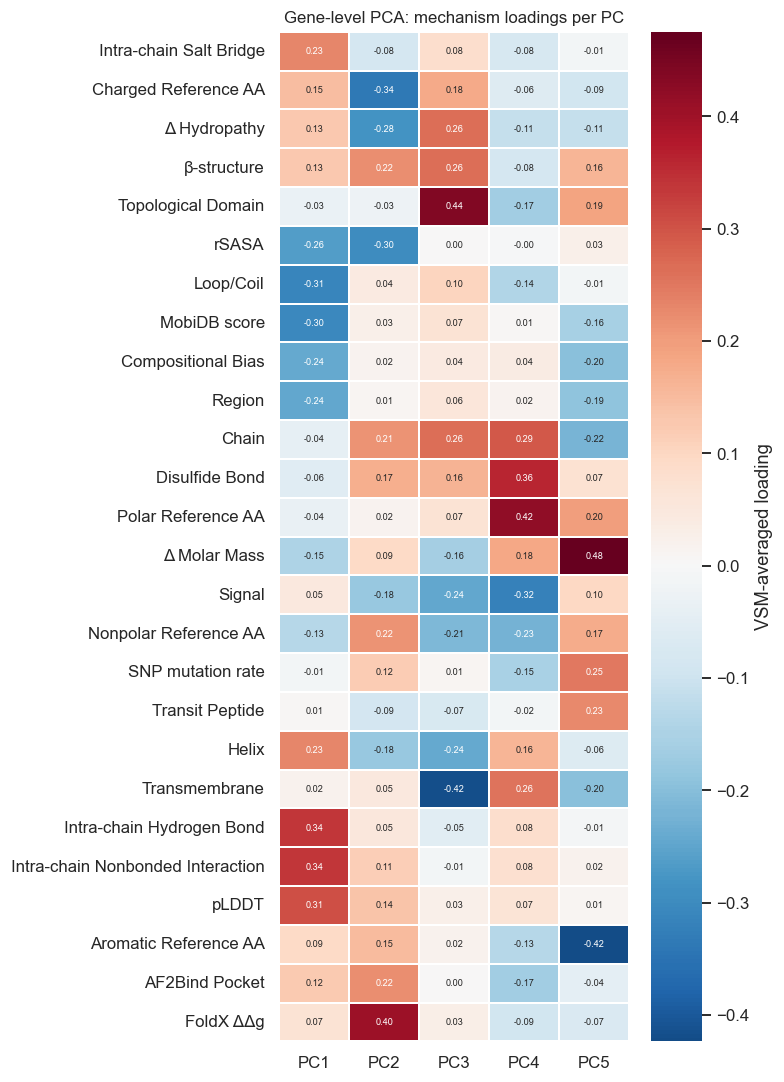

In [18]:
# Fig 2a: full mechanism-loading heatmap (final_pca.ipynb's approach: keep any
# mechanism with |loading| > 0.2 on at least one PC, order rows by Ward clustering
# of their 5-PC loading profile)
from scipy.spatial.distance import pdist

PC_COLS = PC_NAMES
THRESHOLD = 0.22

loadings_filtered = loadings_g[loadings_g[PC_COLS].abs().gt(THRESHOLD).any(axis=1)]

Z = linkage(loadings_filtered[PC_COLS].values, method="ward", metric="euclidean")
ROW_ORDER = loadings_filtered.index[leaves_list(Z)]

fig, ax = plt.subplots(figsize=(7, 10))
sns.heatmap(loadings_filtered.loc[ROW_ORDER, PC_COLS], cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6}, linewidths=0.3, ax=ax, cbar_kws={"label": "VSM-averaged loading"})
#ax.set_title(f"Gene-level PCA: mechanism loadings per PC\n(|loading| > {THRESHOLD} in >=1 PC, PhyloP excluded)", fontsize=11)
ax.set_title(f"Gene-level PCA: mechanism loadings per PC", fontsize=11)
ax.set(xlabel="", ylabel="")
fig.tight_layout()
fig.savefig(OUTDIR / "fig2a_gene_level_loadings.png", dpi=200, bbox_inches="tight")
plt.show()


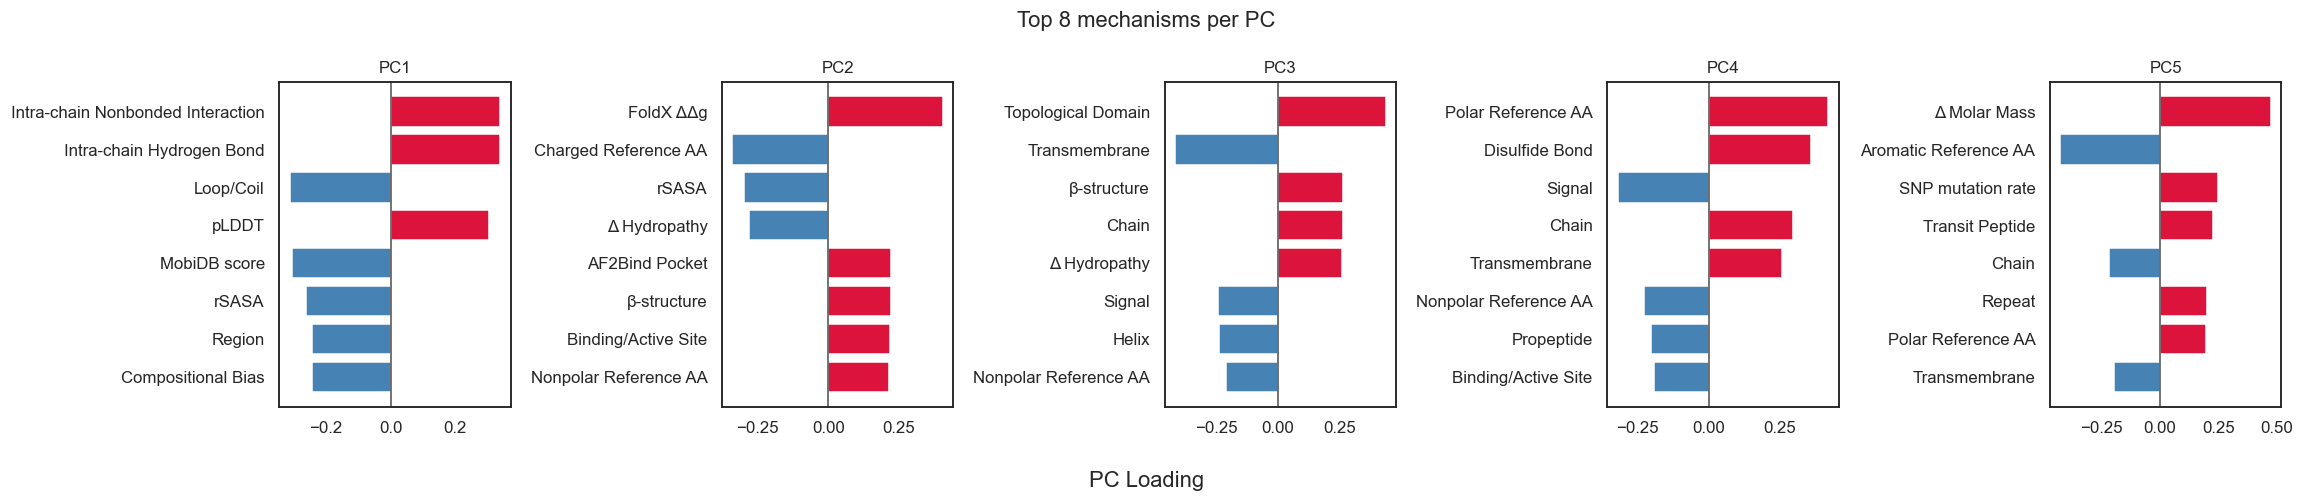

In [19]:
# Fig 2b: top loadings per PC, isolating each axis's theme
num_mech = 8
fig, axes = plt.subplots(1, N_PCS, figsize=(4.2 * N_PCS, 4.5))
for ax, pc in zip(axes, PC_NAMES):
    top = loadings_g[pc].reindex(loadings_g[pc].abs().sort_values(ascending=False).index[:num_mech])
    top = top.iloc[::-1]
    colors = ["crimson" if v > 0 else "steelblue" for v in top]
    ax.barh(top.index, top.values, color=colors)
    ax.axvline(0, color="0.3", lw=1)
    ax.set_title(pc, fontsize=11)
fig.suptitle(f"Top {num_mech} mechanisms per PC")
fig.supxlabel("PC Loading")
fig.tight_layout()
fig.savefig(OUTDIR / "fig2b_top_mechanisms_per_pc.png", dpi=200, bbox_inches="tight")
plt.show()


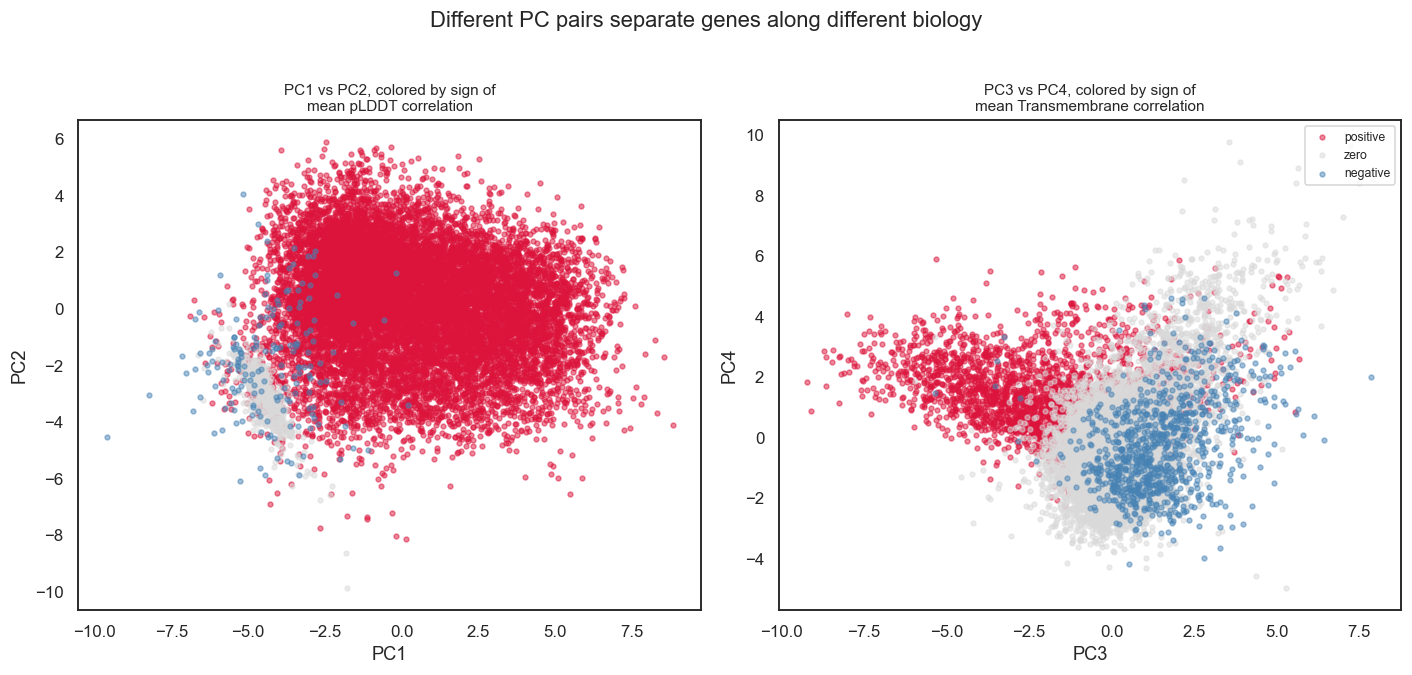

In [20]:
# Fig 2c (i): PC1 x PC2 colored by sign of mean pLDDT correlation, and PC3 x PC4
# colored by sign of mean Transmembrane correlation -- mirrors pca_v6_narrative.ipynb's
# original two-panel Fig 2c layout (one mechanism per panel, not a 6-mechanism grid)
mech_avg_g = mech.groupby(level="gene").mean()
palette = {"positive": "crimson", "zero": "0.85", "negative": "steelblue"}
hue_order = ["positive", "zero", "negative"]

def signed_scatter(ax, pc_x, pc_y, scores, mech_col):
    pc_df = pd.DataFrame(scores[:, [PC_NAMES.index(pc_x), PC_NAMES.index(pc_y)]],
                          columns=[pc_x, pc_y], index=gene_avg.index).reset_index()
    merged = pc_df.merge(mech_avg_g[[mech_col]], left_on="gene", right_index=True, how="left")
    sign = np.select([merged[mech_col] > 0, merged[mech_col] == 0, merged[mech_col] < 0],
                      hue_order, default="zero")
    for label in hue_order:
        m = sign == label
        ax.scatter(merged.loc[m, pc_x], merged.loc[m, pc_y], s=10, alpha=0.5,
                   color=palette[label], label=label)
    ax.set_xlabel(pc_x)
    ax.set_ylabel(pc_y)
    ax.set_title(f"{pc_x} vs {pc_y}, colored by sign of\nmean {mech_col} correlation", fontsize=10)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
signed_scatter(axes[0], "PC1", "PC2", scores_g, "pLDDT")
signed_scatter(axes[1], "PC3", "PC4", scores_g, "Transmembrane")
axes[1].legend(title="", fontsize=8, loc="upper right")
fig.suptitle("Different PC pairs separate genes along different biology", y=1.02)
fig.tight_layout()
fig.savefig(OUTDIR / "fig2c_1_pc1_pc2_by_mechanism.png", dpi=200, bbox_inches="tight")
plt.show()

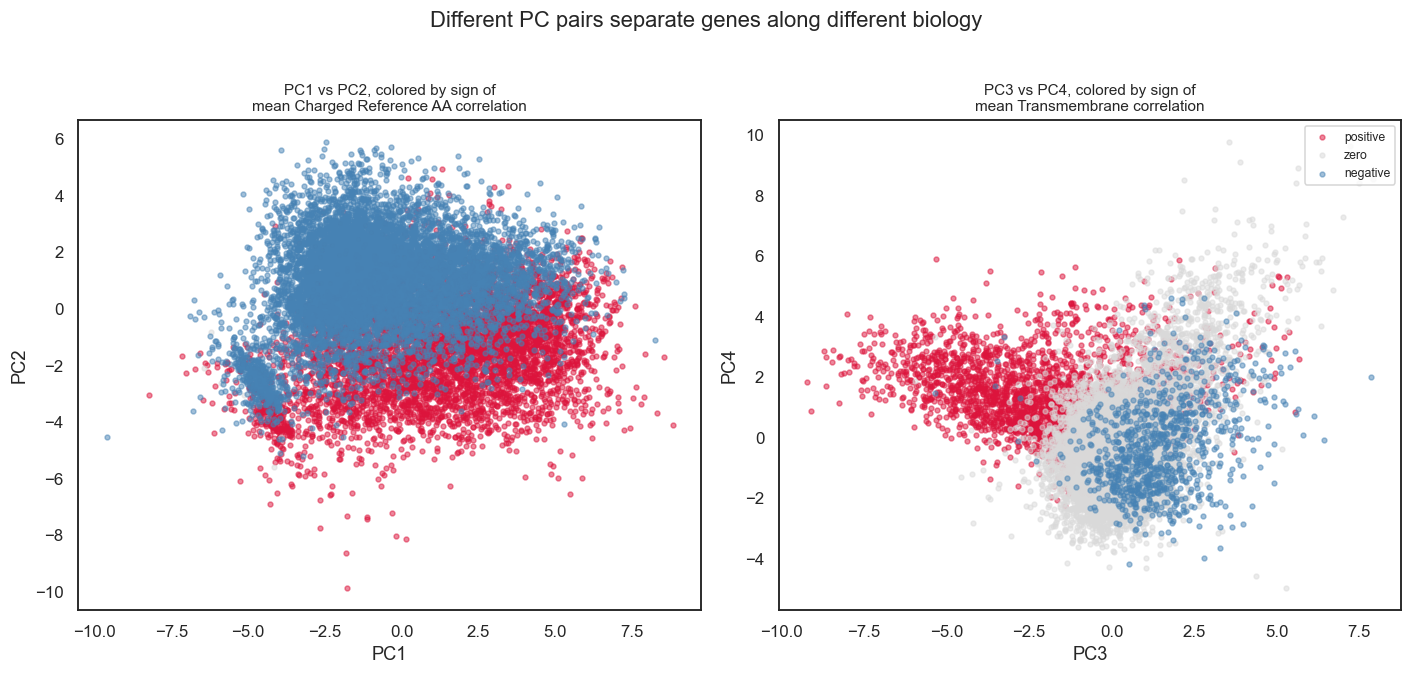

In [21]:
# Fig 2c (ii): PC1 x PC2 colored by sign of mean Charged-Reference-AA correlation,
# and PC3 x PC4 colored by sign of mean Transmembrane correlation again
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
signed_scatter(axes[0], "PC1", "PC2", scores_g, "Charged Reference AA")
signed_scatter(axes[1], "PC3", "PC4", scores_g, "Transmembrane")
axes[1].legend(title="", fontsize=8, loc="upper right")
fig.suptitle("Different PC pairs separate genes along different biology", y=1.02)
fig.tight_layout()
fig.savefig(OUTDIR / "fig2c_2_pc3_pc4_by_mechanism.png", dpi=200, bbox_inches="tight")
plt.show()

### Supplementary: variance explained, expanded mechanism grids, and PC-independence diagnostics

The full 6-mechanism-per-panel versions of Fig 2c, the gene-level scree plot, and two direction diagnostics (`compare_pcs` / `compare_pc_genes`) checking that PC3 and PC4 are genuinely independent axes, both in mechanism loadings and in which genes they pick out.

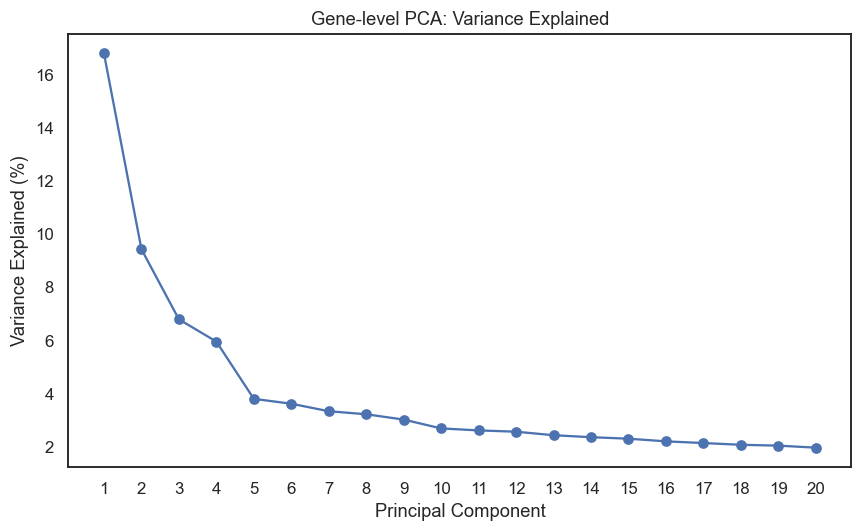

In [22]:
# variance explained
n_pcs = 20

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, n_pcs + 1),
    pca_g.explained_variance_ratio_[:n_pcs] * 100,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Gene-level PCA: Variance Explained")

plt.xticks(range(1, n_pcs + 1))
plt.tight_layout()
plt.savefig(OUTDIR / "gene_level_variance_explained.png", dpi=200, bbox_inches="tight")
plt.show()

In [23]:
# let's look at the average correlations
mech_avg_g = mech.groupby(level="gene").mean()
palette = {
    "positive_avg_corr": "tab:blue",
    "no_avg_corr": "tab:gray",
    "negative_avg_corr": "tab:red",
}

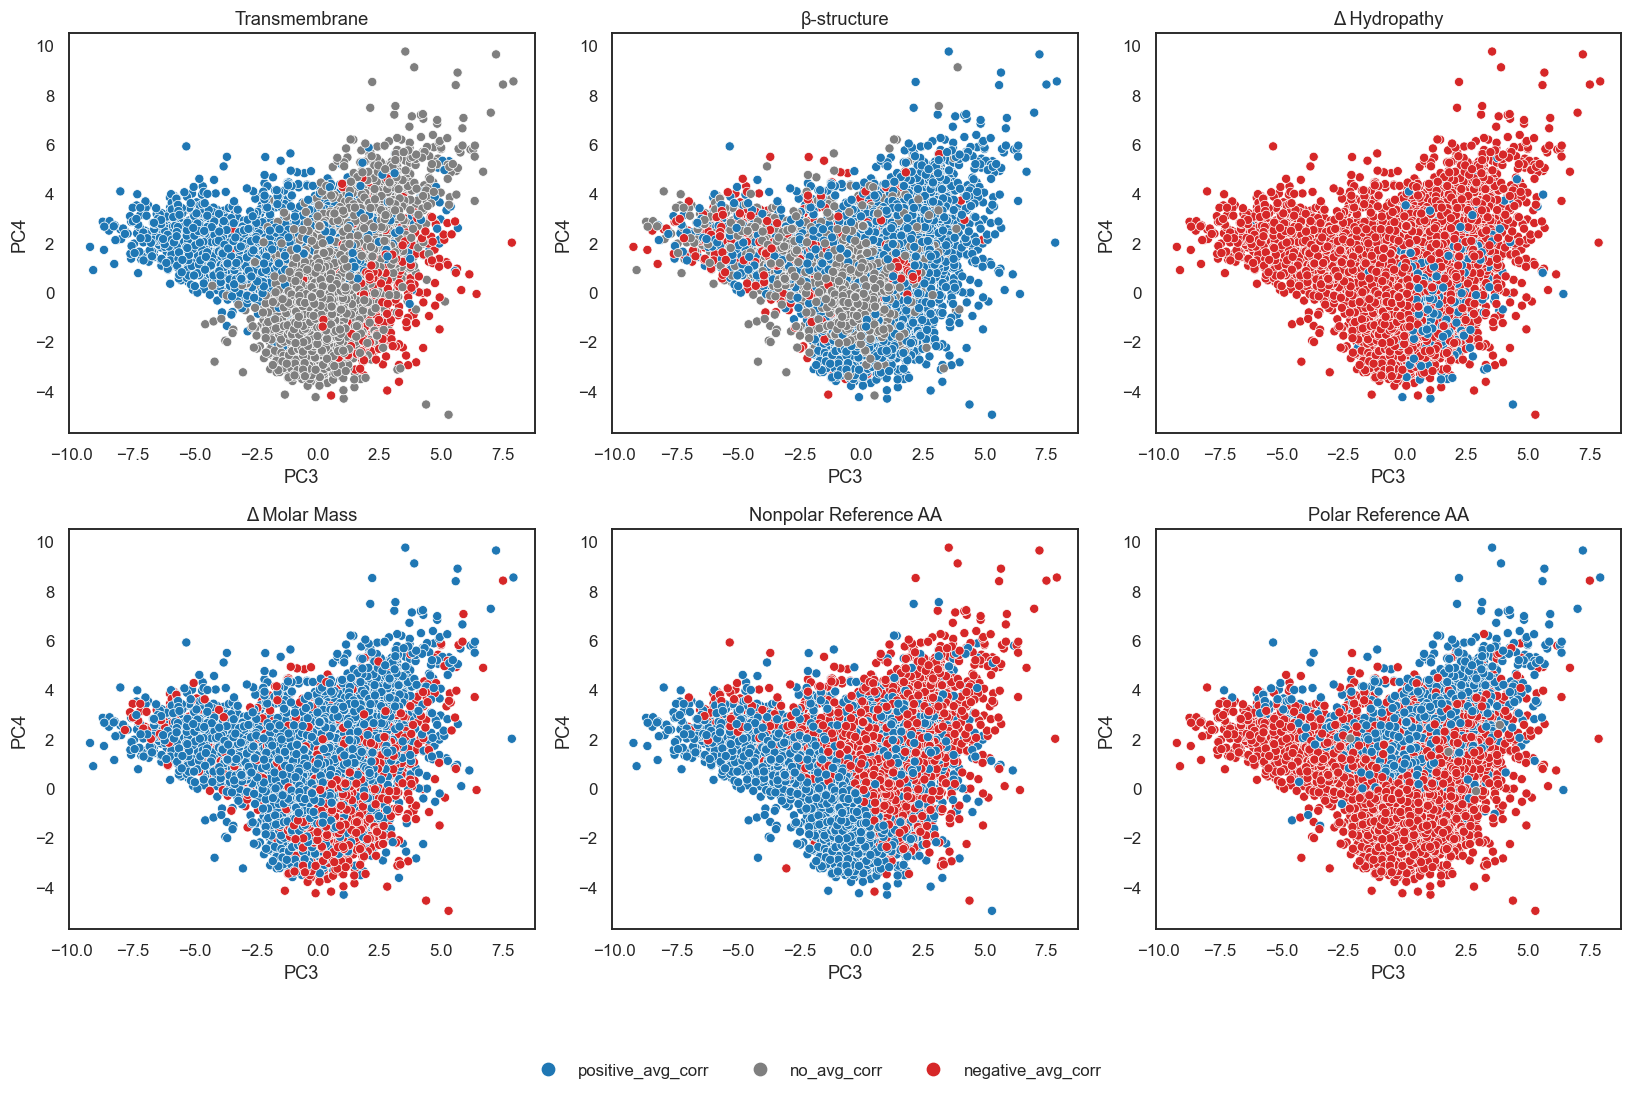

In [24]:
from matplotlib.lines import Line2D

# plotting the PC space: PC3 vs PC4
pc_df = pd.DataFrame(
    scores_g[:, [2, 3]],
    columns=["PC3", "PC4"],
    index=gene_avg.index
).reset_index()

# add average correlations
pc_df_mech_corr = pc_df.merge(
    mech_avg_g,
    left_on="gene",
    right_index=True,
    how="left"
)

pc_df_mech_corr[MECHS] = pc_df_mech_corr[MECHS].apply(
    lambda col: np.select(
        [col > 0, col == 0, col < 0],
        ["positive_avg_corr", "no_avg_corr", "negative_avg_corr"],
        default="no_avg_corr",
    )
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

hue_cols = [
    "Transmembrane",
    "β-structure",
    "Δ Hydropathy",
    "Δ Molar Mass",
    "Nonpolar Reference AA",
    "Polar Reference AA",
]

hue_order = [
    "positive_avg_corr",
    "no_avg_corr",
    "negative_avg_corr"
]

for ax, hue_col in zip(axes.flat, hue_cols):
    sns.scatterplot(
        data=pc_df_mech_corr,
        x="PC3",
        y="PC4",
        hue=hue_col,
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        legend=False
    )
    ax.set_title(hue_col)

# Create legend handles manually
handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=palette[label],
        markeredgecolor=palette[label],
        markersize=8,
        label=label
    )
    for label in hue_order
]

# One shared legend
fig.legend(
    handles=handles,
    labels=hue_order,
    loc="lower center",
    ncol=3,
    frameon=False,
    title=None
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    OUTDIR / "gene_level_PCA3_PCA4_pc_space.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

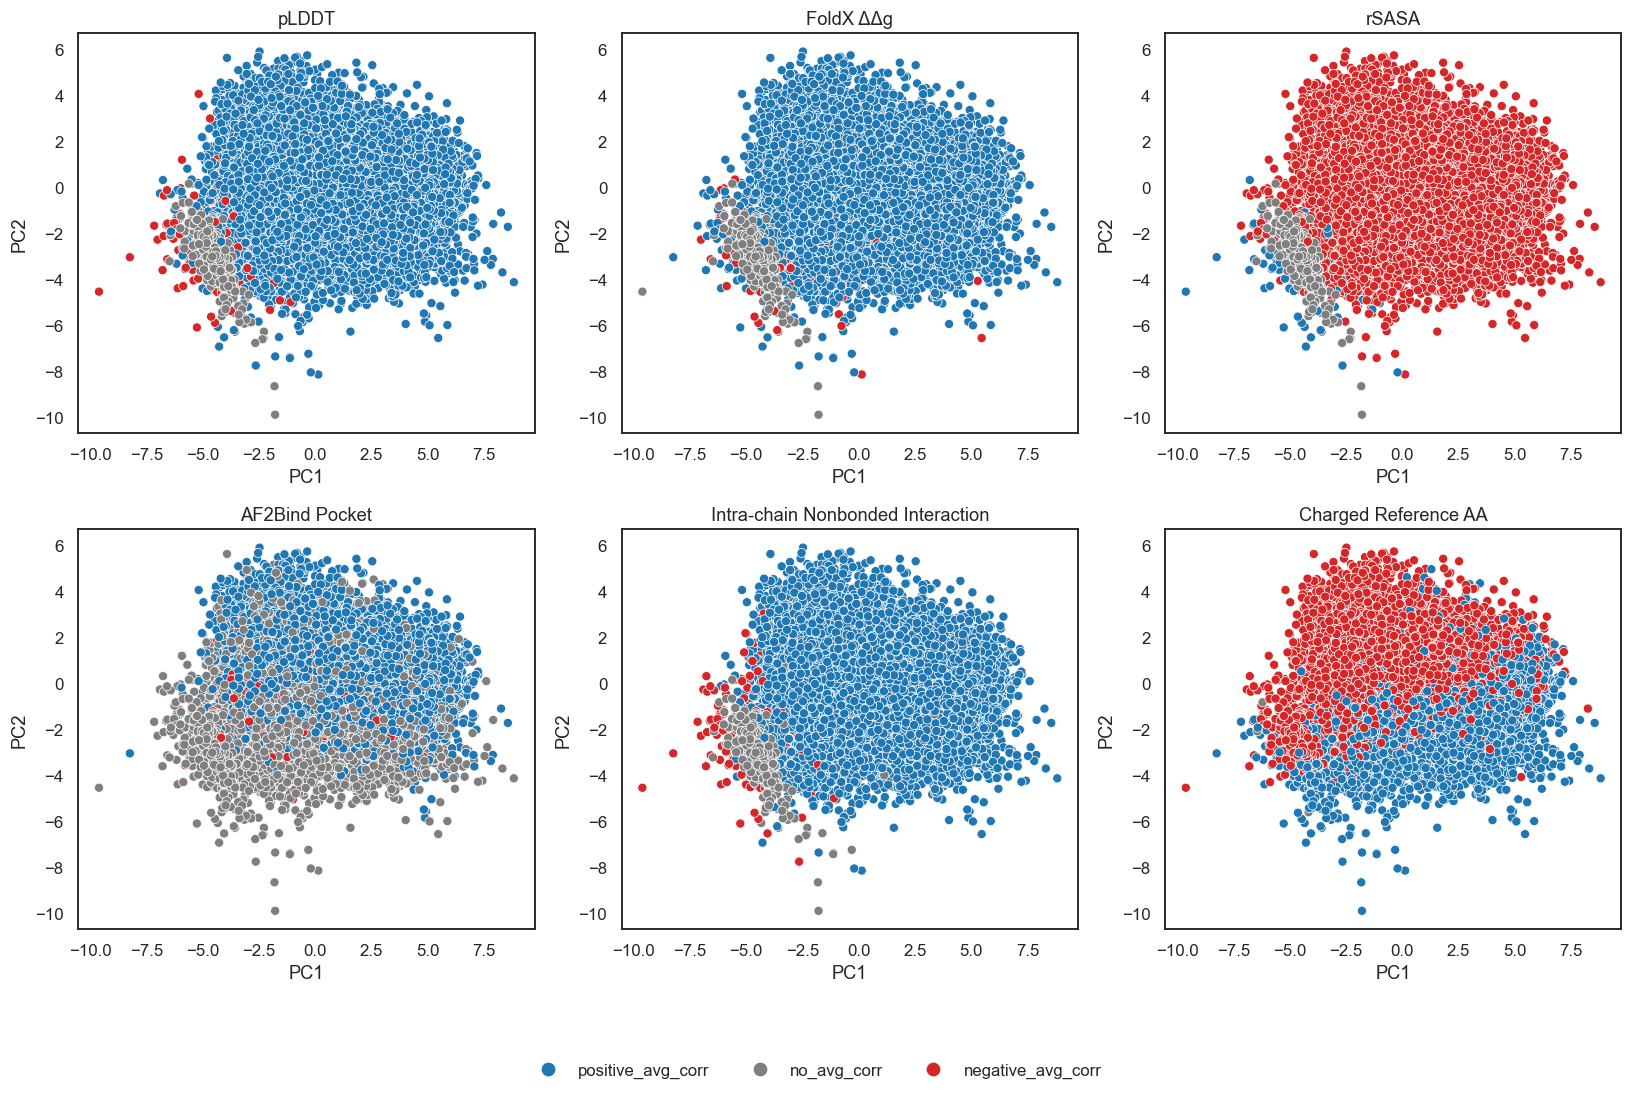

In [25]:
# plotting the PC space: PC1 vs PC2
pc_df = pd.DataFrame(
    scores_g[:, [0, 1]],
    columns=["PC1", "PC2"],
    index=gene_avg.index
).reset_index()

# add average correlations
pc_df_mech_corr = pc_df.merge(
    mech_avg_g,
    left_on="gene",
    right_index=True,
    how="left"
)

pc_df_mech_corr[MECHS] = pc_df_mech_corr[MECHS].apply(
    lambda col: np.select(
        [col > 0, col == 0, col < 0],
        ["positive_avg_corr", "no_avg_corr", "negative_avg_corr"],
        default="no_avg_corr",
    )
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

hue_cols = [
    "pLDDT",
    "FoldX ΔΔg",
    "rSASA",
    "AF2Bind Pocket",
    "Intra-chain Nonbonded Interaction",
    "Charged Reference AA",
]

hue_order = [
    "positive_avg_corr",
    "no_avg_corr",
    "negative_avg_corr"
]

for ax, hue_col in zip(axes.flat, hue_cols):
    sns.scatterplot(
        data=pc_df_mech_corr,
        x="PC1",
        y="PC2",
        hue=hue_col,
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        legend=False
    )
    ax.set_title(hue_col)

# Create legend handles manually
handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=palette[label],
        markeredgecolor=palette[label],
        markersize=8,
        label=label
    )
    for label in hue_order
]

# One shared legend
fig.legend(
    handles=handles,
    labels=hue_order,
    loc="lower center",
    ncol=3,
    frameon=False,
    title=None
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    OUTDIR / "gene_level_PCA1_PCA2_pc_space.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

PC3 vs PC4 (consensus loadings, 43 mechanisms)
  cosine                  +0.016   (-1 = opposite, 0 = orthogonal)
  Pearson r               +0.024
  mechanisms flipping sign  23/43 = 53%   (~50% expected for unrelated PCs, 100% for opposite)


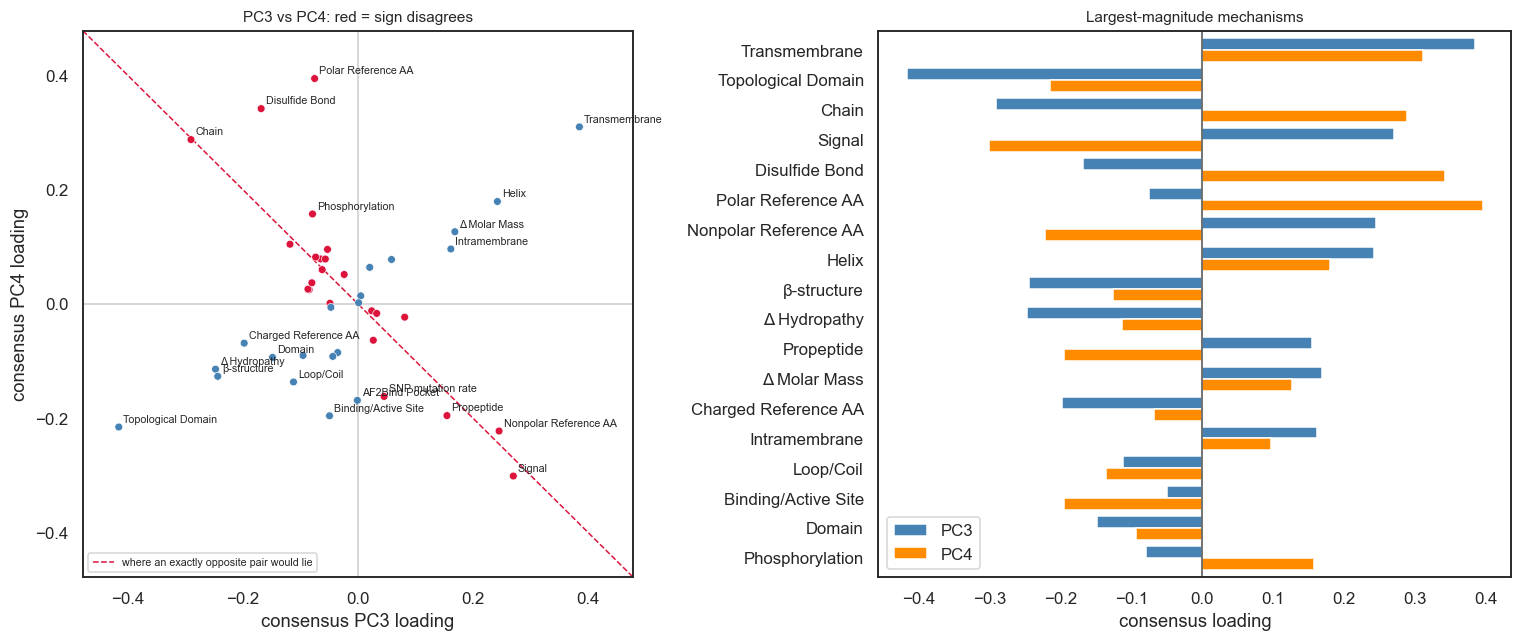

In [26]:
def compare_pcs(pc_a, pc_b, label_threshold=0.12, save=True):
    """Head-to-head direction check for two PCs of the consensus loading matrix."""
    a, b = consensus[pc_a], consensus[pc_b]
    flip = np.sign(a) != np.sign(b)

    print(f"{pc_a} vs {pc_b} (consensus loadings, {len(a)} mechanisms)")
    print(f"  cosine                  {cosine(a, b):+.3f}   (-1 = opposite, 0 = orthogonal)")
    print(f"  Pearson r               {a.corr(b):+.3f}")
    print(f"  mechanisms flipping sign  {flip.sum()}/{len(a)} = {flip.mean():.0%}"
          f"   (~50% expected for unrelated PCs, 100% for opposite)")

    big = (a.abs() > label_threshold) | (b.abs() > label_threshold)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                   gridspec_kw={"width_ratios": [1, 1.15]})

    ax1.axhline(0, color="0.8", lw=1)
    ax1.axvline(0, color="0.8", lw=1)
    lim = max(a.abs().max(), b.abs().max()) * 1.15
    ax1.plot([-lim, lim], [lim, -lim], ls="--", c="crimson", lw=1,
             label="where an exactly opposite pair would lie")
    ax1.scatter(a, b, s=26, c=np.where(flip, "crimson", "steelblue"),
                edgecolor="white", linewidth=0.4, zorder=3)
    for m in a.index[big]:
        ax1.annotate(m, (a[m], b[m]), fontsize=7, xytext=(3, 3),
                     textcoords="offset points")
    ax1.set(xlabel=f"consensus {pc_a} loading", ylabel=f"consensus {pc_b} loading",
            xlim=(-lim, lim), ylim=(-lim, lim))
    ax1.set_title(f"{pc_a} vs {pc_b}: red = sign disagrees", fontsize=10)
    ax1.legend(fontsize=7, loc="lower left")

    top = pd.concat([a, b], axis=1).loc[
        (a.abs() + b.abs()).sort_values(ascending=False).index[:18]
    ]
    top.plot.barh(ax=ax2, color={pc_a: "steelblue", pc_b: "darkorange"}, width=0.8)
    ax2.axvline(0, color="0.3", lw=1)
    ax2.invert_yaxis()
    ax2.set(xlabel="consensus loading", ylabel="")
    ax2.set_title("Largest-magnitude mechanisms", fontsize=10)

    fig.tight_layout()
    if save:
        fig.savefig(OUTDIR / f"direction_{pc_a}_vs_{pc_b}.png", dpi=200,
                    bbox_inches="tight")
    plt.show()
    return pd.DataFrame({pc_a: a, pc_b: b, "sign_flips": flip})


pc3_vs_pc4 = compare_pcs("PC3", "PC4")

In [27]:
def gene_scores_frame(vsm):
    """Aligned PC scores for every gene, from the vsm's own PCA (§3)."""
    return pd.DataFrame(scores[vsm][:, :N_PCS], index=mech.xs(vsm, level="vsm").index, columns=PC_NAMES)


def top_genes(vsm, pc, n=10, n_mechs=8):
    """Genes at both extremes of one aligned PC, with the mechanisms the PC's
    loading weighs most heavily, for a check that high |score| genes actually
    carry the values the loading implies."""
    s = gene_scores_frame(vsm)[pc].sort_values()
    ends = pd.concat([s.head(n), s.tail(n)])
    top_mechs = loadings[vsm][pc].abs().sort_values(ascending=False).head(n_mechs).index
    profile = mech.xs(vsm, level="vsm").loc[ends.index, top_mechs]
    return pd.concat([ends.rename("score"), profile], axis=1)

PC3 vs PC4 (gene scores, AlphaMissense)
  Pearson r                 +0.000   (~0 expected -- PCA scores are uncorrelated)
  top-20 |score| overlap    1/20   Jaccard 0.026
  genes in both top-20:     ['ENSG00000171136']


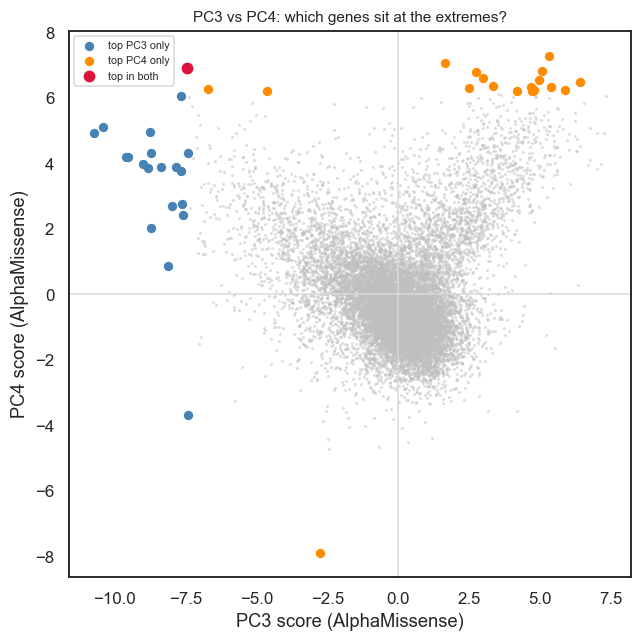

In [28]:
def compare_pc_genes(pc_a, pc_b, vsm=REFERENCE, n=20, save=True):
    """Head-to-head check of which genes sit at the extremes of two aligned PCs.

    The gene-level analog of `compare_pcs` (§4a): that function checked whether
    two PCs are opposite *mechanism* patterns; this checks whether they pick out
    the same *genes*, using `vsm`'s own aligned scores (§3).
    """
    frame = gene_scores_frame(vsm)
    a, b = frame[pc_a], frame[pc_b]

    top_a = set(a.abs().sort_values(ascending=False).head(n).index)
    top_b = set(b.abs().sort_values(ascending=False).head(n).index)
    shared = top_a & top_b

    print(f"{pc_a} vs {pc_b} (gene scores, {vsm})")
    print(f"  Pearson r                 {a.corr(b):+.3f}   (~0 expected -- PCA scores are uncorrelated)")
    print(f"  top-{n} |score| overlap    {len(shared)}/{n}   Jaccard {len(shared) / len(top_a | top_b):.3f}")
    if shared:
        print(f"  genes in both top-{n}:     {sorted(shared)}")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axhline(0, color="0.85", lw=1)
    ax.axvline(0, color="0.85", lw=1)
    ax.scatter(a, b, s=4, c="0.75", linewidth=0, alpha=0.5, zorder=1)
    only_a, only_b = list(top_a - shared), list(top_b - shared)
    ax.scatter(a[only_a], b[only_a], s=26, c="steelblue", label=f"top {pc_a} only", zorder=2)
    ax.scatter(a[only_b], b[only_b], s=26, c="darkorange", label=f"top {pc_b} only", zorder=2)
    if shared:
        ax.scatter(a[list(shared)], b[list(shared)], s=45, c="crimson", label="top in both", zorder=3)
    ax.set(xlabel=f"{pc_a} score ({vsm})", ylabel=f"{pc_b} score ({vsm})")
    ax.set_title(f"{pc_a} vs {pc_b}: which genes sit at the extremes?", fontsize=10)
    ax.legend(fontsize=7, loc="best")
    fig.tight_layout()
    if save:
        fig.savefig(OUTDIR / f"gene_scores_{pc_a}_vs_{pc_b}.png", dpi=200, bbox_inches="tight")
    plt.show()

    return pd.DataFrame({pc_a: a, pc_b: b}).loc[sorted(top_a | top_b)]


pc3_vs_pc4_genes = compare_pc_genes("PC3", "PC4")

## 3. Are these axes biologically real, or PCA noise? (GO enrichment)

For each PC, every gene is ranked once by its PC score, then for each GO term the sum of its member genes' ranks is compared to the mean/variance expected for a same-sized random group (a closed-form rank-sum z-score — fast, but anti-conservative since genes within a GO term are often correlated; treat it as triage, not a calibrated GSEA). Only **BP** and **MF** terms are used (it drops **CC**), and a term only counts if at least `FAST_MIN_GENES` (100) of its genes are present.


In [29]:
GO_ASPECTS = ["BP", "MF"]  # drops CC
FAST_MIN_GENES = 100
GO_OUTDIR = OUTDIR / "go_enrichment"
GO_OUTDIR.mkdir(exist_ok=True)

go_annot = pd.read_csv("../reference_data/uniprot_go_ensg.tsv", sep="\t")
go_annot = go_annot[["ensg", "go_id", "go", "aspect"]].drop_duplicates()

go_term_name = (
    go_annot.drop_duplicates("go_id")
    .assign(term_name=lambda d: d["go"].str.replace(r"\s*\[GO:\d+\]$", "", regex=True))
    .set_index("go_id")["term_name"]
)

def go_genesets_all(aspect):
    sub = go_annot[go_annot.aspect == aspect]
    return sub.groupby("go_id")["ensg"].apply(lambda s: sorted(set(s))).to_dict()

GENESETS_ALL = {aspect: go_genesets_all(aspect) for aspect in GO_ASPECTS}

def fast_zscores(ranked_scores, aspect, min_genes=FAST_MIN_GENES):
    """Rank-sum z-score (closed-form normal approx) for every substantial GO
    term against every column of `ranked_scores` (genes x PCs, index = ENSG)."""
    genes = ranked_scores.index
    n_genes = len(genes)
    pos = pd.Series(np.arange(n_genes), index=genes)

    terms = {}
    for go_id, members in GENESETS_ALL[aspect].items():
        idx = pos.reindex(members).dropna().astype(int).to_numpy()
        if len(idx) >= min_genes:
            terms[go_id] = idx

    out = {}
    for pc in ranked_scores.columns:
        ranks = rankdata(ranked_scores[pc].to_numpy())
        mean_rank = (n_genes + 1) / 2
        z = {}
        for go_id, idx in terms.items():
            n = len(idx)
            R = ranks[idx].sum()
            mu = n * mean_rank
            sigma = np.sqrt(n * (n_genes - n) * (n_genes + 1) / 12)
            z[go_id] = (R - mu) / sigma
        out[pc] = pd.Series(z)

    result = pd.DataFrame(out)
    result.index.name = "go_id"
    return result

gene_level_ranked = pd.DataFrame(scores_g[:, :N_PCS], index=gene_avg.index, columns=PC_NAMES)
fast_z_gene = {aspect: fast_zscores(gene_level_ranked, aspect) for aspect in GO_ASPECTS}
print(f"n substantial terms per aspect: { {a: len(z) for a, z in fast_z_gene.items()} }")


n substantial terms per aspect: {'BP': 81, 'MF': 69}


In [30]:
frames = []
for aspect, z in fast_z_gene.items():
    f = z.reset_index()
    f.insert(1, "aspect", aspect)
    f.insert(2, "term_name", f["go_id"].map(go_term_name))
    frames.append(f)
fast_gene_long = pd.concat(frames, ignore_index=True)
fast_gene_long["max_abs_z"] = fast_gene_long[PC_NAMES].abs().max(axis=1)
print(f"{len(fast_gene_long)} substantial GO terms total (BP+MF, >={FAST_MIN_GENES} genes)")


150 substantial GO terms total (BP+MF, >=100 genes)


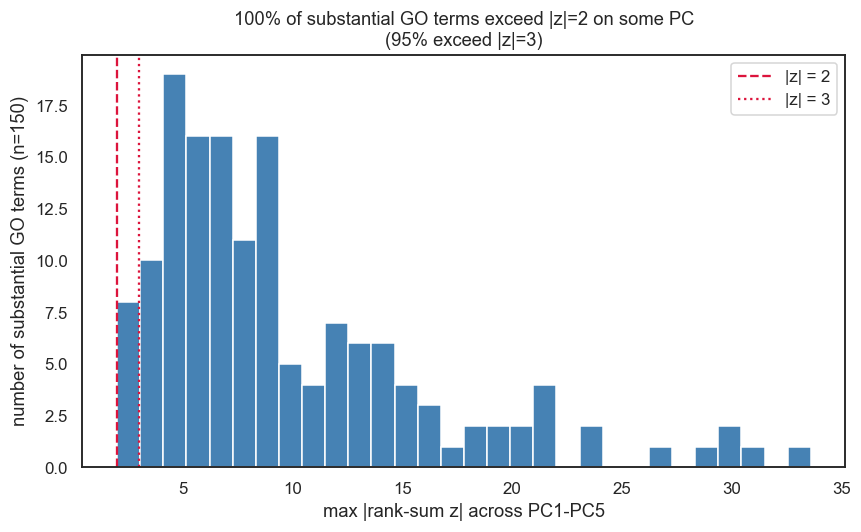

In [31]:
# Fig 3a: are these axes pervasively biologically real?
pct2 = (fast_gene_long["max_abs_z"] >= 2).mean() * 100
pct3 = (fast_gene_long["max_abs_z"] >= 3).mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(fast_gene_long["max_abs_z"], bins=30, color="steelblue", edgecolor="white")
ax.axvline(2, color="crimson", ls="--", lw=1.5, label="|z| = 2")
ax.axvline(3, color="crimson", ls=":", lw=1.5, label="|z| = 3")
ax.set(xlabel="max |rank-sum z| across PC1-PC5",
       ylabel=f"number of substantial GO terms (n={len(fast_gene_long)})")
ax.set_title(f"{pct2:.0f}% of substantial GO terms exceed |z|=2 on some PC\n({pct3:.0f}% exceed |z|=3)")
ax.legend()
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3a_go_enrichment_pervasive.png", dpi=200, bbox_inches="tight")
plt.show()


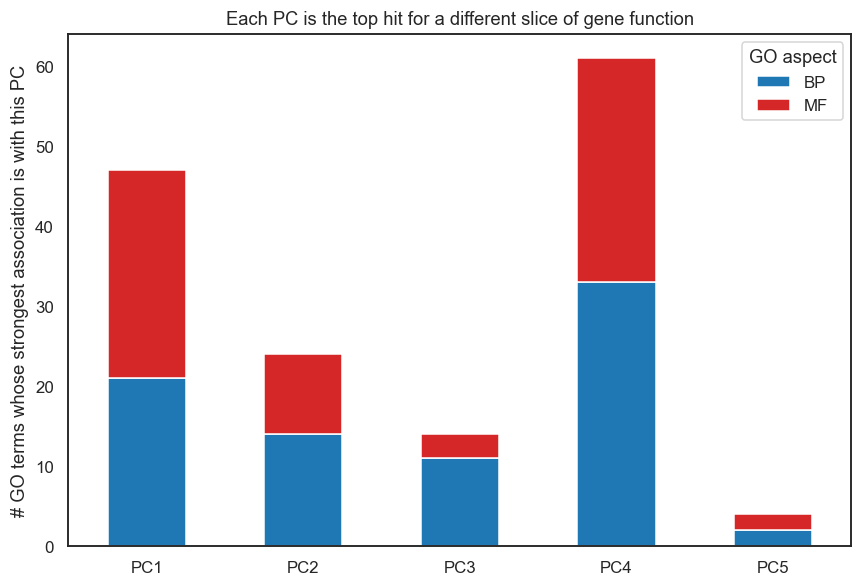

In [32]:
# Fig 3b: each PC is the top hit for a different slice of GO terms
argmax_pc = fast_gene_long[PC_NAMES].abs().idxmax(axis=1)
counts = fast_gene_long.assign(argmax_pc=argmax_pc).groupby(["argmax_pc", "aspect"]).size().unstack(fill_value=0)
counts = counts.reindex(PC_NAMES)

fig, ax = plt.subplots(figsize=(8, 5.5))
counts.plot(kind="bar", stacked=True, ax=ax, color={"BP": "tab:blue", "MF": "tab:red"})
ax.set(xlabel="", ylabel="# GO terms whose strongest association is with this PC")
ax.set_title("Each PC is the top hit for a different slice of gene function")
ax.legend(title="GO aspect")
plt.xticks(rotation=0)
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3b_argmax_pc_by_aspect.png", dpi=200, bbox_inches="tight")
plt.show()


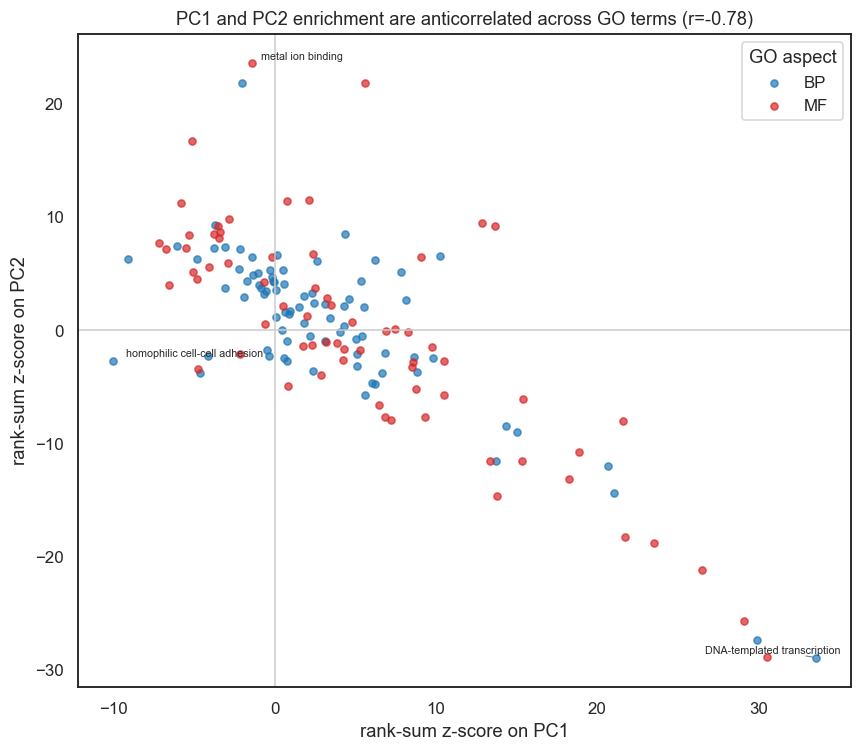

In [33]:
# Fig 3c: PC1 vs PC2 enrichment across all substantial GO terms
r = fast_gene_long["PC1"].corr(fast_gene_long["PC2"])

fig, ax = plt.subplots(figsize=(8, 7))
colors = {"BP": "tab:blue", "MF": "tab:red"}
for aspect, sub in fast_gene_long.groupby("aspect"):
    ax.scatter(sub["PC1"], sub["PC2"], s=22, alpha=0.7, color=colors[aspect], label=aspect)
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)

# label a few extreme terms (adjustText spreads overlapping labels apart)
picked, seen_ids = [], set()
for col, asc in [("PC2", False), ("PC2", True), ("PC1", False), ("PC1", True)]:
    row = fast_gene_long.sort_values(col, ascending=asc).iloc[0]
    if row["go_id"] not in seen_ids:
        seen_ids.add(row["go_id"])
        picked.append(row)
texts = [ax.text(row["PC1"], row["PC2"], row["term_name"][:30], fontsize=7) for row in picked]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.4", lw=0.6))

ax.set(xlabel="rank-sum z-score on PC1", ylabel="rank-sum z-score on PC2")
ax.set_title(f"PC1 and PC2 enrichment are anticorrelated across GO terms (r={r:+.2f})")
ax.legend(title="GO aspect")
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3c_pc1_pc2_anticorrelated.png", dpi=200, bbox_inches="tight")
plt.show()


In [34]:
# Fig 3c prep: per-GO-term disorder & surface-protein composition
# `gf` has one row per UniProt isoform, so duplicate ENSGs are collapsed first
# (they agree almost everywhere). Disorder quartile/proportion are missing for
# genes without a resolved structure, so those are dropped from the disorder
# averages; surface_protein is a complete annotation where NaN means "not a
# surface protein", so it's treated as False.
disorder_cols = ["proportion_disordered_q1_low", "proportion_disordered_q2",
                  "proportion_disordered_q3", "proportion_disordered_q4_high"]
gf_gene = gf.set_index("ensg")
quartile_score = gf_gene[disorder_cols].notna().to_numpy() @ np.arange(1, 5)
quartile_score = pd.Series(np.where(quartile_score == 0, np.nan, quartile_score), index=gf_gene.index)
disorder_quartile = quartile_score.groupby(level=0).mean()
disorder_proportion = gf_gene["proportion_disordered"].groupby(level=0).mean()
is_surface = gf_gene["surface_protein"].eq(True).groupby(level=0).any()

analysis_genes = gene_avg.index  # same gene universe the GO enrichment ran over

def term_composition(aspect, go_id):
    members = pd.Index(GENESETS_ALL[aspect][go_id]).intersection(analysis_genes)
    dq = disorder_quartile.reindex(members).dropna()
    dp = disorder_proportion.reindex(members).dropna()
    s = is_surface.reindex(members)
    return pd.Series({
        "mean_disorder_quartile": dq.mean() if len(dq) else np.nan,
        "mean_disorder_proportion": dp.mean() if len(dp) else np.nan,
        "pct_surface": s.mean() * 100 if len(s) else np.nan,
    })

composition = fast_gene_long.apply(lambda row: term_composition(row["aspect"], row["go_id"]), axis=1)
fast_gene_long = pd.concat([fast_gene_long, composition], axis=1)
fast_gene_long["surface_bin"] = pd.cut(
    fast_gene_long["pct_surface"], bins=[-0.1, 25, 50, 75, 100],
    labels=["0-25%", "25-50%", "50-75%", "75-100%"],
)
print(fast_gene_long[["mean_disorder_quartile", "mean_disorder_proportion", "pct_surface"]].describe())

       mean_disorder_quartile  mean_disorder_proportion  pct_surface
count              150.000000                150.000000   150.000000
mean                 2.618624                  0.350505    13.946429
std                  0.461190                  0.103017    18.767721
min                  1.378378                  0.110554     0.000000
25%                  2.376684                  0.294328     1.278797
50%                  2.598680                  0.331869     7.501172
75%                  2.847175                  0.399494    18.217939
max                  3.786207                  0.634693    92.800000


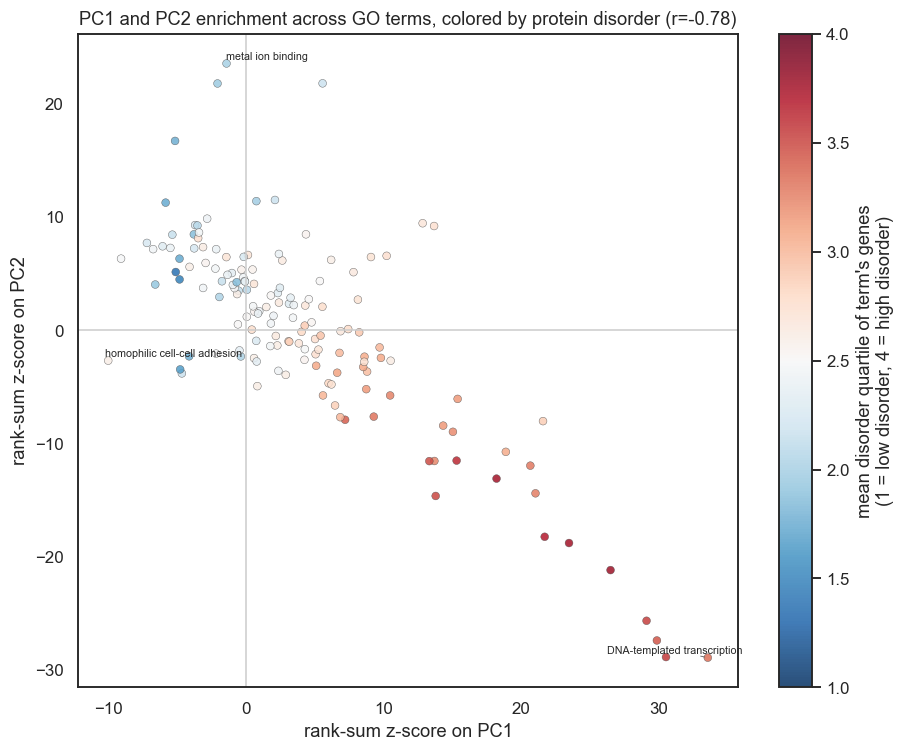

In [35]:
# Fig 3c (disorder): same PC1 x PC2 layout as Fig 3c, colored by each GO
# term's mean disorder quartile (1 = least disordered genes, 4 = most)
fig, ax = plt.subplots(figsize=(8.5, 7))
sca = ax.scatter(fast_gene_long["PC1"], fast_gene_long["PC2"], s=26, alpha=0.85,
                  c=fast_gene_long["mean_disorder_quartile"], cmap="RdBu_r",
                  vmin=1, vmax=4, edgecolor="0.3", linewidth=0.3)
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)

# label a few extreme terms (adjustText spreads overlapping labels apart)
picked, seen_ids = [], set()
for col, asc in [("PC2", False), ("PC2", True), ("PC1", False), ("PC1", True)]:
    row = fast_gene_long.sort_values(col, ascending=asc).iloc[0]
    if row["go_id"] not in seen_ids:
        seen_ids.add(row["go_id"])
        picked.append(row)
texts = [ax.text(row["PC1"], row["PC2"], row["term_name"][:30], fontsize=7) for row in picked]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.4", lw=0.6))

cbar = fig.colorbar(sca, ax=ax)
cbar.set_label("mean disorder quartile of term's genes\n(1 = low disorder, 4 = high disorder)")
ax.set(xlabel="rank-sum z-score on PC1", ylabel="rank-sum z-score on PC2")
ax.set_title(f"PC1 and PC2 enrichment across GO terms, colored by protein disorder (r={r:+.2f})")
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3c_pc1_pc2_by_disorder.png", dpi=200, bbox_inches="tight")
plt.show()

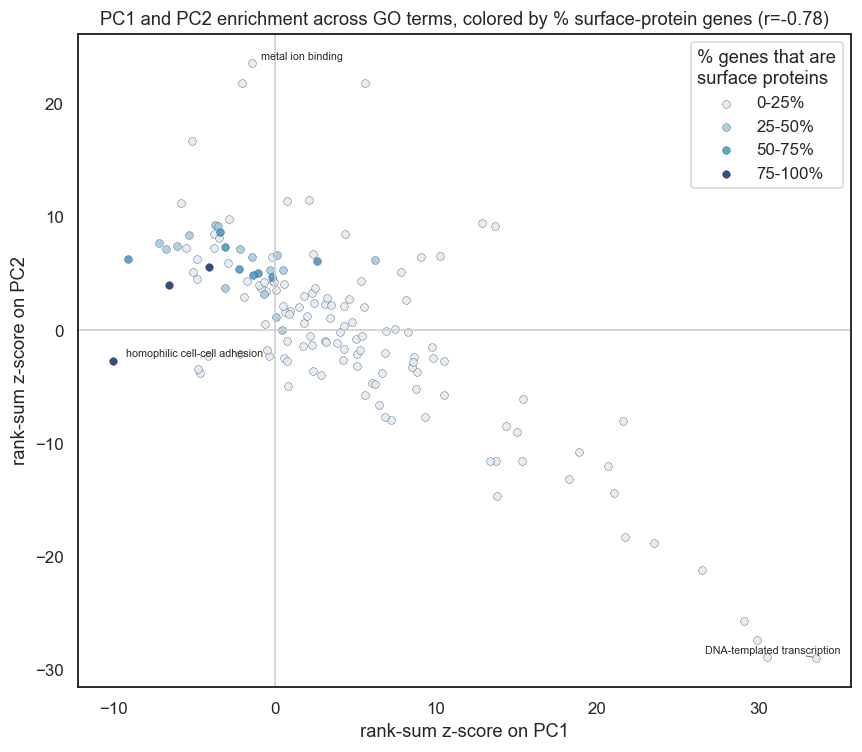

In [36]:
# Fig 3c (surface): same layout, colored by the % of each term's genes that
# are surface proteins, binned into quartiles of percentage
fig, ax = plt.subplots(figsize=(8, 7))
surface_colors = {"0-25%": "#deebf7", "25-50%": "#9ecae1", "50-75%": "#4292c6", "75-100%": "#08306b"}
for bin_label in surface_colors:
    sub = fast_gene_long[fast_gene_long["surface_bin"] == bin_label]
    if len(sub):
        ax.scatter(sub["PC1"], sub["PC2"], s=26, alpha=0.85, color=surface_colors[bin_label],
                   edgecolor="0.3", linewidth=0.3, label=bin_label)
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)

# label a few extreme terms (adjustText spreads overlapping labels apart)
picked, seen_ids = [], set()
for col, asc in [("PC2", False), ("PC2", True), ("PC1", False), ("PC1", True)]:
    row = fast_gene_long.sort_values(col, ascending=asc).iloc[0]
    if row["go_id"] not in seen_ids:
        seen_ids.add(row["go_id"])
        picked.append(row)
texts = [ax.text(row["PC1"], row["PC2"], row["term_name"][:30], fontsize=7) for row in picked]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.4", lw=0.6))

ax.set(xlabel="rank-sum z-score on PC1", ylabel="rank-sum z-score on PC2")
ax.set_title(f"PC1 and PC2 enrichment across GO terms, colored by % surface-protein genes (r={r:+.2f})")
ax.legend(title="% genes that are\nsurface proteins")
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3c_pc1_pc2_by_surface.png", dpi=200, bbox_inches="tight")
plt.show()

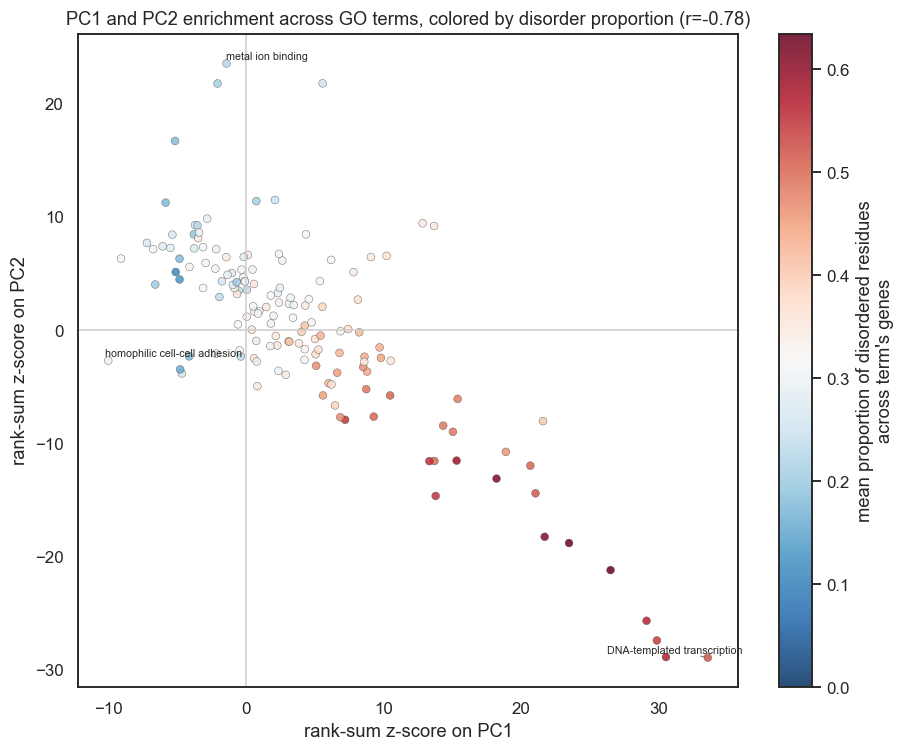

In [37]:
# Fig 3c (disorder, continuous): same PC1 x PC2 layout, colored by each GO
# term's mean raw proportion of disordered residues (rather than the quartile
# bucket used above)
fig, ax = plt.subplots(figsize=(8.5, 7))
vmax = fast_gene_long["mean_disorder_proportion"].max()
sca = ax.scatter(fast_gene_long["PC1"], fast_gene_long["PC2"], s=26, alpha=0.85,
                  c=fast_gene_long["mean_disorder_proportion"], cmap="RdBu_r",
                  vmin=0, vmax=vmax, edgecolor="0.3", linewidth=0.3)
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)

# label a few extreme terms (adjustText spreads overlapping labels apart)
picked, seen_ids = [], set()
for col, asc in [("PC2", False), ("PC2", True), ("PC1", False), ("PC1", True)]:
    row = fast_gene_long.sort_values(col, ascending=asc).iloc[0]
    if row["go_id"] not in seen_ids:
        seen_ids.add(row["go_id"])
        picked.append(row)
texts = [ax.text(row["PC1"], row["PC2"], row["term_name"][:30], fontsize=7) for row in picked]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.4", lw=0.6))

cbar = fig.colorbar(sca, ax=ax)
cbar.set_label("mean proportion of disordered residues\nacross term's genes")
ax.set(xlabel="rank-sum z-score on PC1", ylabel="rank-sum z-score on PC2")
ax.set_title(f"PC1 and PC2 enrichment across GO terms, colored by disorder proportion (r={r:+.2f})")
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3c_pc1_pc2_by_disorder_proportion.png", dpi=200, bbox_inches="tight")
plt.show()

In [38]:
# Fig 3d prep: per-GO-term average gene PC1/PC2 loading -- a classic PCA
# scatter (gene PC1 score vs. gene PC2 score) aggregated to one point per GO
# term instead of one point per gene, reusing the same gene sets and disorder/
# surface composition columns computed for Fig 3c
gene_pc12 = pd.DataFrame(scores_g[:, :2], columns=["PC1", "PC2"], index=gene_avg.index)

def term_avg_pc(aspect, go_id):
    members = pd.Index(GENESETS_ALL[aspect][go_id]).intersection(analysis_genes)
    sub = gene_pc12.reindex(members)
    return pd.Series({"avg_PC1": sub["PC1"].mean(), "avg_PC2": sub["PC2"].mean()})

avg_pc = fast_gene_long.apply(lambda row: term_avg_pc(row["aspect"], row["go_id"]), axis=1)
fast_gene_long[["avg_PC1", "avg_PC2"]] = avg_pc
r_d = fast_gene_long["avg_PC1"].corr(fast_gene_long["avg_PC2"])
print(fast_gene_long[["avg_PC1", "avg_PC2"]].describe())

          avg_PC1     avg_PC2
count  150.000000  150.000000
mean     0.604411    0.128072
std      1.204449    0.893399
min     -2.561345   -1.918935
25%     -0.193044   -0.402089
50%      0.435057    0.249069
75%      1.431004    0.746011
max      3.654124    3.289586


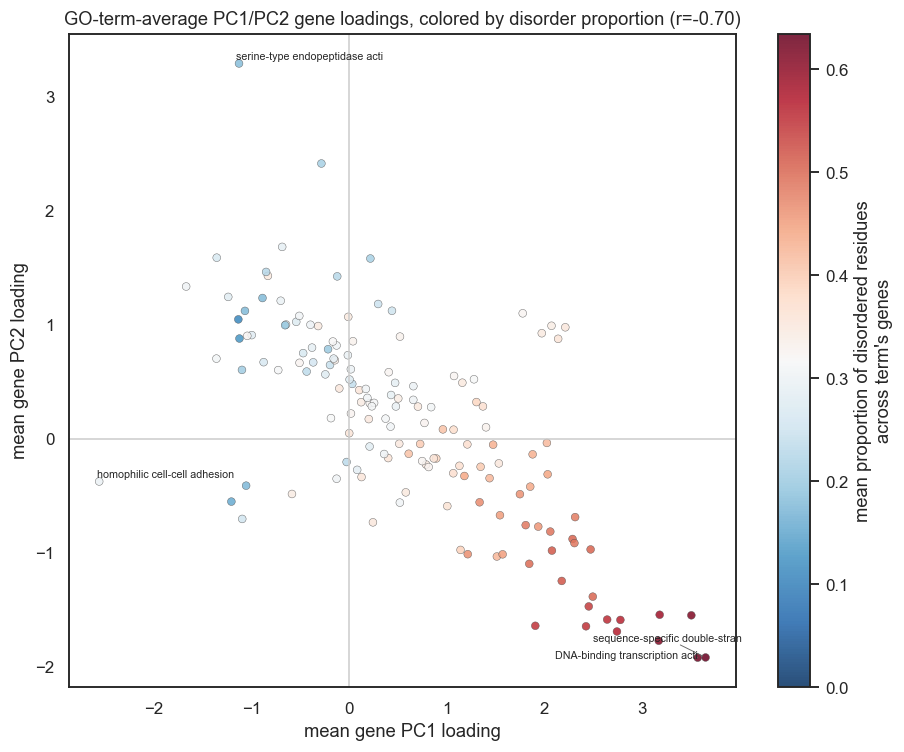

In [39]:
# Fig 3d (i): GO-term-average PC1 vs PC2 gene loadings, colored by mean
# disorder proportion (continuous)
fig, ax = plt.subplots(figsize=(8.5, 7))
vmax = fast_gene_long["mean_disorder_proportion"].max()
sca = ax.scatter(fast_gene_long["avg_PC1"], fast_gene_long["avg_PC2"], s=26, alpha=0.85,
                  c=fast_gene_long["mean_disorder_proportion"], cmap="RdBu_r",
                  vmin=0, vmax=vmax, edgecolor="0.3", linewidth=0.3)
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)

picked, seen_ids = [], set()
for col, asc in [("avg_PC2", False), ("avg_PC2", True), ("avg_PC1", False), ("avg_PC1", True)]:
    row = fast_gene_long.sort_values(col, ascending=asc).iloc[0]
    if row["go_id"] not in seen_ids:
        seen_ids.add(row["go_id"])
        picked.append(row)
texts = [ax.text(row["avg_PC1"], row["avg_PC2"], row["term_name"][:30], fontsize=7) for row in picked]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.4", lw=0.6))

cbar = fig.colorbar(sca, ax=ax)
cbar.set_label("mean proportion of disordered residues\nacross term's genes")
ax.set(xlabel="mean gene PC1 loading", ylabel="mean gene PC2 loading")
ax.set_title(f"GO-term-average PC1/PC2 gene loadings, colored by disorder proportion (r={r_d:+.2f})")
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3d_pc1_pc2_avg_by_disorder_proportion.png", dpi=200, bbox_inches="tight")
plt.show()

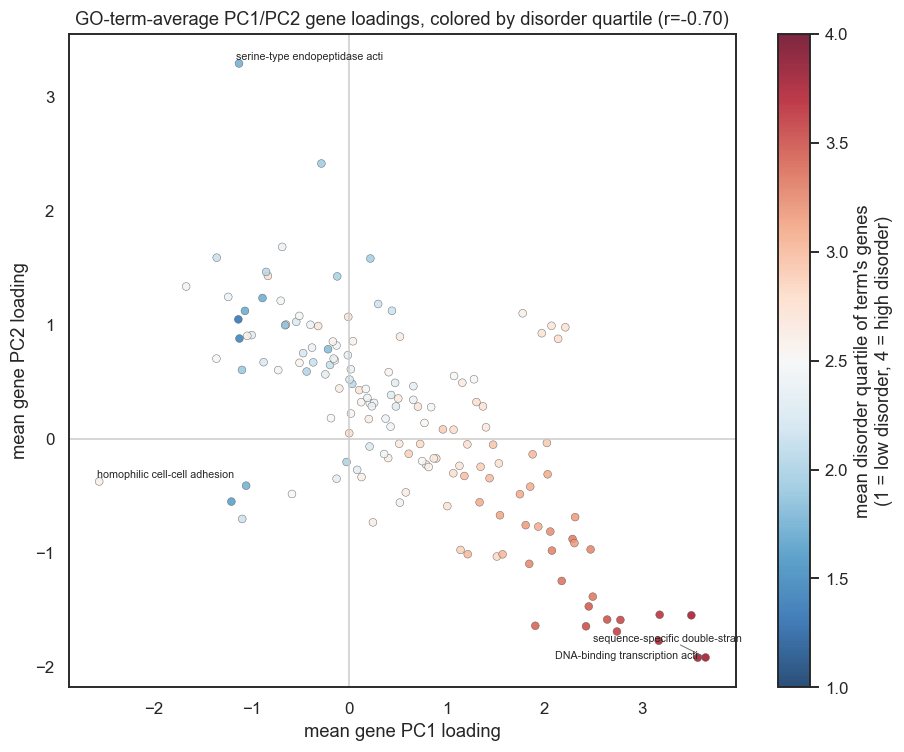

In [40]:
# Fig 3d (ii): same GO-term-average loading plot, colored by mean disorder
# quartile (1 = least disordered genes, 4 = most)
fig, ax = plt.subplots(figsize=(8.5, 7))
sca = ax.scatter(fast_gene_long["avg_PC1"], fast_gene_long["avg_PC2"], s=26, alpha=0.85,
                  c=fast_gene_long["mean_disorder_quartile"], cmap="RdBu_r",
                  vmin=1, vmax=4, edgecolor="0.3", linewidth=0.3)
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)

picked, seen_ids = [], set()
for col, asc in [("avg_PC2", False), ("avg_PC2", True), ("avg_PC1", False), ("avg_PC1", True)]:
    row = fast_gene_long.sort_values(col, ascending=asc).iloc[0]
    if row["go_id"] not in seen_ids:
        seen_ids.add(row["go_id"])
        picked.append(row)
texts = [ax.text(row["avg_PC1"], row["avg_PC2"], row["term_name"][:30], fontsize=7) for row in picked]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.4", lw=0.6))

cbar = fig.colorbar(sca, ax=ax)
cbar.set_label("mean disorder quartile of term's genes\n(1 = low disorder, 4 = high disorder)")
ax.set(xlabel="mean gene PC1 loading", ylabel="mean gene PC2 loading")
ax.set_title(f"GO-term-average PC1/PC2 gene loadings, colored by disorder quartile (r={r_d:+.2f})")
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3d_pc1_pc2_avg_by_disorder_quartile.png", dpi=200, bbox_inches="tight")
plt.show()

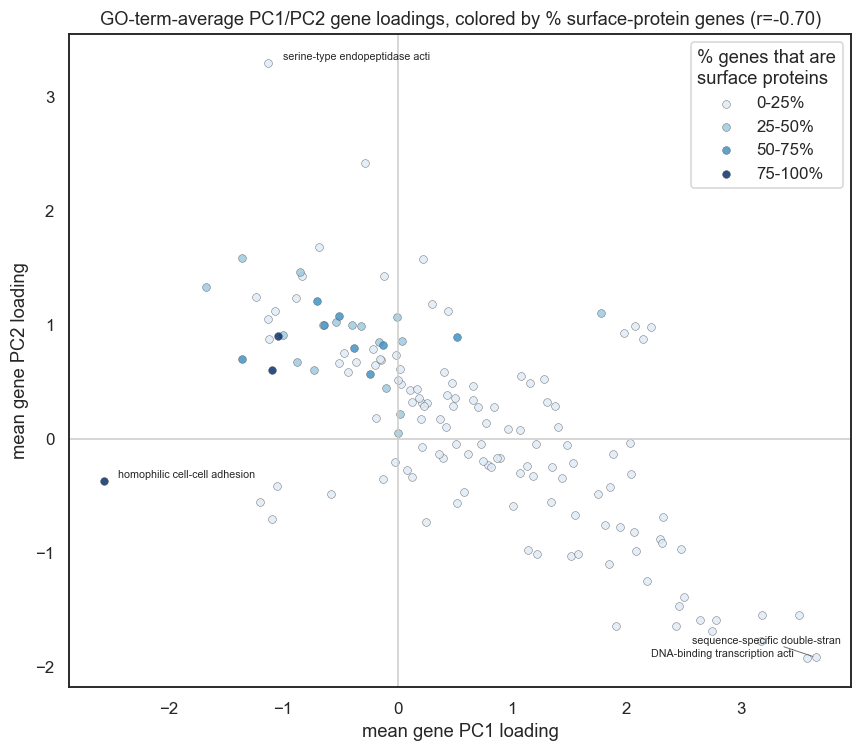

In [41]:
# Fig 3d (iii): same GO-term-average loading plot, colored by the % of each
# term's genes that are surface proteins, binned the same way as Fig 3c
fig, ax = plt.subplots(figsize=(8, 7))
surface_colors = {"0-25%": "#deebf7", "25-50%": "#9ecae1", "50-75%": "#4292c6", "75-100%": "#08306b"}
for bin_label in surface_colors:
    sub = fast_gene_long[fast_gene_long["surface_bin"] == bin_label]
    if len(sub):
        ax.scatter(sub["avg_PC1"], sub["avg_PC2"], s=26, alpha=0.85, color=surface_colors[bin_label],
                   edgecolor="0.3", linewidth=0.3, label=bin_label)
ax.axhline(0, color="0.8", lw=1)
ax.axvline(0, color="0.8", lw=1)

picked, seen_ids = [], set()
for col, asc in [("avg_PC2", False), ("avg_PC2", True), ("avg_PC1", False), ("avg_PC1", True)]:
    row = fast_gene_long.sort_values(col, ascending=asc).iloc[0]
    if row["go_id"] not in seen_ids:
        seen_ids.add(row["go_id"])
        picked.append(row)
texts = [ax.text(row["avg_PC1"], row["avg_PC2"], row["term_name"][:30], fontsize=7) for row in picked]
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="0.4", lw=0.6))

ax.set(xlabel="mean gene PC1 loading", ylabel="mean gene PC2 loading")
ax.set_title(f"GO-term-average PC1/PC2 gene loadings, colored by % surface-protein genes (r={r_d:+.2f})")
ax.legend(title="% genes that are\nsurface proteins")
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig3d_pc1_pc2_avg_by_surface.png", dpi=200, bbox_inches="tight")
plt.show()

## 4. Case study: the top GO term

Following `final_pca.ipynb`, the case study uses **GO:0006351 (DNA-templated transcription)** — whichever GO term ranks highest by max |z| in §3.


### Ranking candidate GO terms

`final_pca.ipynb`'s original ranking -- the top 10 substantial GO terms overall by max |z|, with no similarity filtering -- shown first, then the three refined, similarity-filtered versions this narrative developed on top of it.

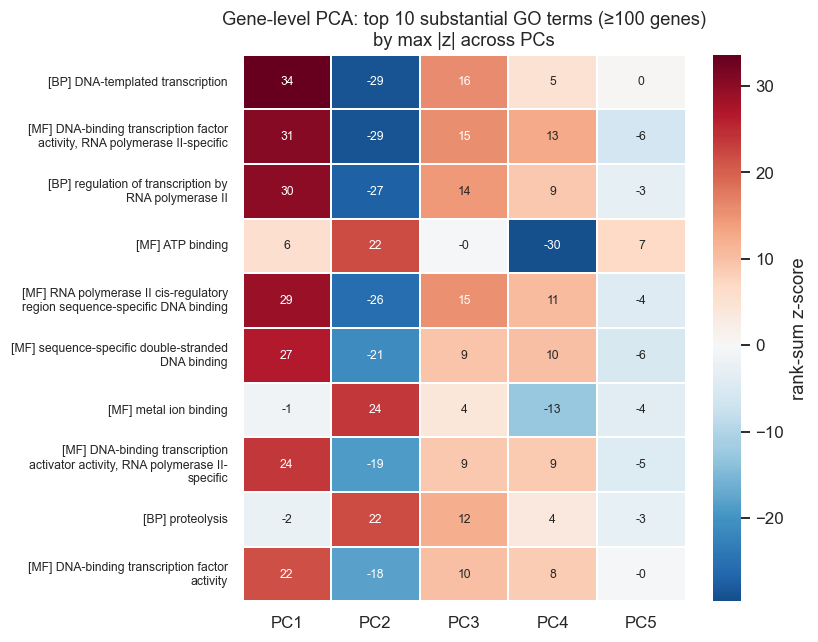

In [42]:
import textwrap

TOP_N_FAST = 10
WRAP_WIDTH = 38

frames = []
for aspect, z in fast_z_gene.items():
    f = z.reset_index()
    f.insert(1, "aspect", aspect)
    f.insert(2, "term_name", f["go_id"].map(go_term_name))
    frames.append(f)
fast_gene_long = pd.concat(frames, ignore_index=True)
fast_gene_long["max_abs_z"] = fast_gene_long[PC_NAMES].abs().max(axis=1)

top = fast_gene_long.sort_values("max_abs_z", ascending=False).head(TOP_N_FAST)
labels = [
    textwrap.fill(f"[{aspect}] {term}", WRAP_WIDTH)
    for aspect, term in zip(top["aspect"], top["term_name"])
]
plot_df = top[PC_NAMES].set_axis(labels, axis=0)

fig, ax = plt.subplots(figsize=(7.5, max(4, 0.6 * TOP_N_FAST)))
sns.heatmap(plot_df, cmap="RdBu_r", center=0, annot=True, fmt=".0f", linewidths=0.3,
            cbar_kws={"label": "rank-sum z-score"}, annot_kws={"size": 8}, ax=ax)
ax.set_title(f"Gene-level PCA: top {TOP_N_FAST} substantial GO terms (≥{FAST_MIN_GENES} genes)\nby max |z| across PCs")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fast_gene_level_top_terms_z.png", dpi=200, bbox_inches="tight")
plt.show()

[tie] 'G protein-coupled receptor activity' is the top candidate for PC3 min, PC4 max -- keeping it for PC3 min
[tie] 'DNA-templated transcription' is the top candidate for PC2 min, PC1 max -- keeping it for PC1 max
[PC2 min] skip 'DNA-binding transcription factor activity, RNA polymerase II-specific' (88% gene-set overlap with kept term 'DNA-templated transcription')
[PC2 min] skip 'regulation of transcription by RNA polymerase II' (81% gene-set overlap with kept term 'DNA-templated transcription')
[PC2 min] skip 'RNA polymerase II cis-regulatory region sequence-specific DNA binding' (85% gene-set overlap with kept term 'DNA-templated transcription')
[PC2 min] skip 'sequence-specific double-stranded DNA binding' (84% gene-set overlap with kept term 'DNA-templated transcription')
[PC2 min] skip 'DNA-binding transcription activator activity, RNA polymerase II-specific' (86% gene-set overlap with kept term 'DNA-templated transcription')
[PC2 min] skip 'DNA-binding transcription factor ac

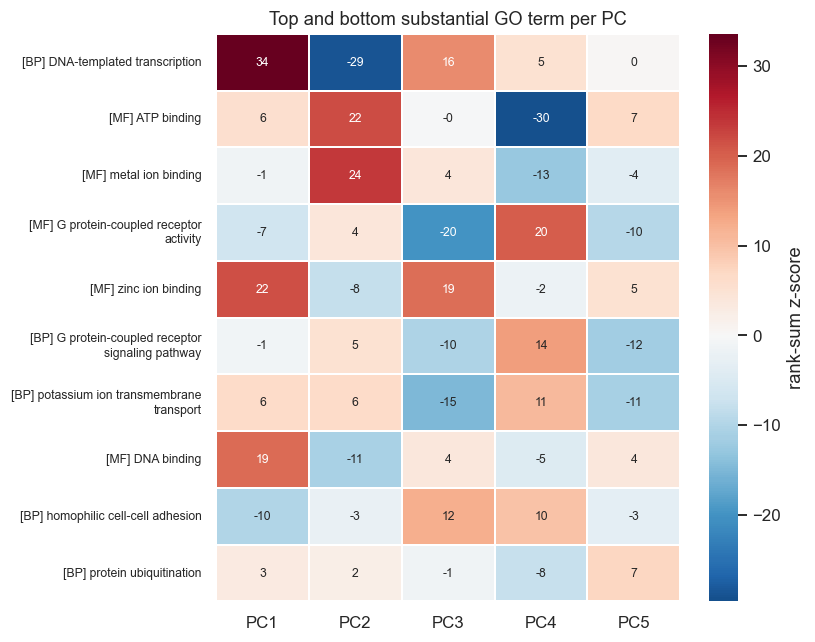

In [43]:
# Fig 4a: for each PC, the most positive (max z) and most negative (min z)
# substantial GO term -- if a slot's best candidate overlaps an already-kept
# term by more than 50% of the smaller gene set (overlap coefficient), skip it
# and backfill with the next-most-significant candidate for that same slot,
# repeating until a sufficiently distinct term is found.
#
# Two resolution rules, applied each round before a slot is finalized:
#  1. If the exact same GO term is currently the top candidate for more than
#     one slot at once (e.g. PC3's min and PC4's max can land on the same
#     term), only the lower-numbered PC is allowed to claim it this round --
#     the other slot simply advances to its next candidate once this term is
#     kept, rather than the two slots racing on raw |z| (which would let a PC4
#     score of 20.3 beat a PC3 score of -20.0 by a coin-flip-sized margin).
#  2. Otherwise, among the remaining eligible slots, whichever currently has
#     the single most extreme |z| candidate gets finalized first (starting
#     from PC1's top hit, the most significant term in the whole dataset).
#SIMILARITY_THRESHOLD = 0.5
SIMILARITY_THRESHOLD = 0.5
WRAP_WIDTH = 38

go_geneset = {go_id: set(members) for aspect in GO_ASPECTS for go_id, members in GENESETS_ALL[aspect].items()}

def overlap_coefficient(a, b):
    return len(a & b) / min(len(a), len(b))

def find_blocker(go_id, kept_ids):
    for k in kept_ids:
        sim = overlap_coefficient(go_geneset[go_id], go_geneset[k])
        if sim > SIMILARITY_THRESHOLD:
            return k, f"{sim:.0%} gene-set overlap"
    return None, None

ranked = {
    (pc, "max"): fast_gene_long.sort_values(pc, ascending=False).reset_index(drop=True)
    for pc in PC_NAMES
}
ranked.update({
    (pc, "min"): fast_gene_long.sort_values(pc, ascending=True).reset_index(drop=True)
    for pc in PC_NAMES
})

cursor = {slot: 0 for slot in ranked}
kept_ids, assigned = [], {}
remaining_slots = set(ranked)

def advance_cursor(slot):
    df = ranked[slot]
    i = cursor[slot]
    while i < len(df):
        cand_id = df.loc[i, "go_id"]
        if cand_id in kept_ids:
            i += 1
            continue
        blocker, reason = find_blocker(cand_id, kept_ids)
        if blocker is not None:
            print(f"[{slot[0]} {slot[1]}] skip {go_term_name[cand_id]!r} "
                  f"({reason} with kept term {go_term_name[blocker]!r})")
            i += 1
            continue
        break
    cursor[slot] = i

while remaining_slots:
    peek = {}
    for slot in list(remaining_slots):
        advance_cursor(slot)
        df = ranked[slot]
        if cursor[slot] < len(df):
            peek[slot] = df.loc[cursor[slot]]
        else:
            print(f"[{slot[0]} {slot[1]}] no sufficiently distinct candidate left -- dropping this slot")
            remaining_slots.discard(slot)
    if not peek:
        break

    # rule 1: resolve same-term ties in favor of the lower-numbered PC
    by_go_id = {}
    for slot, row in peek.items():
        by_go_id.setdefault(row["go_id"], []).append(slot)
    eligible_slots = set()
    for go_id, slots in by_go_id.items():
        if len(slots) > 1:
            winner = min(slots, key=lambda s: PC_NAMES.index(s[0]))
            print(f"[tie] {go_term_name[go_id]!r} is the top candidate for "
                  f"{', '.join(f'{s[0]} {s[1]}' for s in slots)} -- keeping it for {winner[0]} {winner[1]}")
            eligible_slots.add(winner)
        else:
            eligible_slots.add(slots[0])

    # rule 2: among eligible slots, the most significant |z| wins this round
    eligible = {slot: peek[slot] for slot in eligible_slots}
    best_slot = max(eligible, key=lambda s: abs(eligible[s][s[0]]))
    row = peek[best_slot].copy()
    row["pc"], row["direction"] = best_slot
    assigned[best_slot] = row
    kept_ids.append(row["go_id"])
    cursor[best_slot] += 1
    remaining_slots.discard(best_slot)

top_bottom = pd.DataFrame(assigned.values())
top_bottom["z"] = top_bottom.apply(lambda r: r[r["pc"]], axis=1)
top_bottom = top_bottom.sort_values("z", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

# row labels show only the GO aspect and term name (no "[PCx max/min]" prefix)
labels = [textwrap.fill(f"[{r.aspect}] {r.term_name}", WRAP_WIDTH) for r in top_bottom.itertuples()]
plot_df = top_bottom[PC_NAMES].set_axis(labels, axis=0)

fig, ax = plt.subplots(figsize=(7.5, max(4, 0.6 * len(plot_df))))
sns.heatmap(plot_df, cmap="RdBu_r", center=0, annot=True, fmt=".0f", linewidths=0.3,
            cbar_kws={"label": "rank-sum z-score"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Top and bottom substantial GO term per PC")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig4a_top_bottom_go_terms_zscore.png", dpi=200, bbox_inches="tight")
plt.show()

[tie] 'DNA-templated transcription' is the top candidate for PC1, PC2 -- keeping it for PC1
[PC2] skip 'DNA-binding transcription factor activity, RNA polymerase II-specific' (88% gene-set overlap with kept term 'DNA-templated transcription')
[PC2] skip 'regulation of transcription by RNA polymerase II' (81% gene-set overlap with kept term 'DNA-templated transcription')
[PC2] skip 'RNA polymerase II cis-regulatory region sequence-specific DNA binding' (85% gene-set overlap with kept term 'DNA-templated transcription')


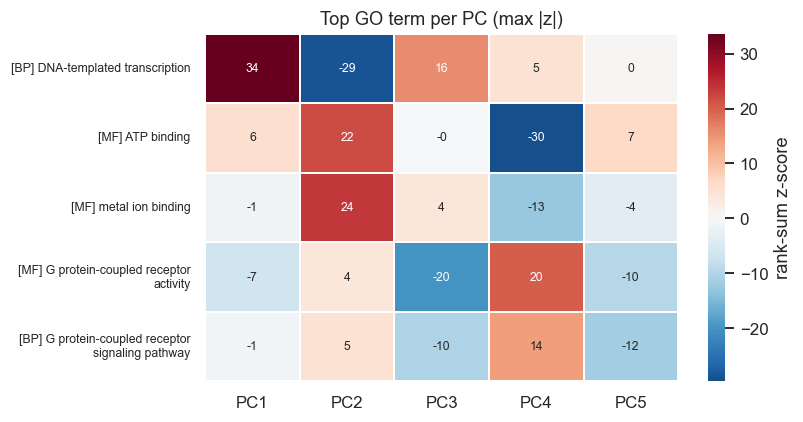

In [44]:
# Fig 4a (alt): one GO term per PC -- just the single most substantial term by
# |z|, in whichever direction (positive or negative) is larger. Same backfill-
# on-overlap logic as the original Fig 4a above, but with one slot per PC
# instead of separate max/min slots (so no same-PC tie rule is needed).
go_geneset = {go_id: set(members) for aspect in GO_ASPECTS for go_id, members in GENESETS_ALL[aspect].items()}
SIMILARITY_THRESHOLD = 0.5
def overlap_coefficient(a, b):
    return len(a & b) / min(len(a), len(b))

def find_blocker(go_id, kept_ids):
    for k in kept_ids:
        sim = overlap_coefficient(go_geneset[go_id], go_geneset[k])
        if sim > SIMILARITY_THRESHOLD:
            return k, f"{sim:.0%} gene-set overlap"
    return None, None

ranked_abs = {
    pc: fast_gene_long.assign(abs_z=fast_gene_long[pc].abs())
        .sort_values("abs_z", ascending=False).reset_index(drop=True)
    for pc in PC_NAMES
}

cursor = {slot: 0 for slot in ranked_abs}
kept_ids, assigned = [], {}
remaining_slots = set(ranked_abs)

def advance_cursor(slot):
    df = ranked_abs[slot]
    i = cursor[slot]
    while i < len(df):
        cand_id = df.loc[i, "go_id"]
        if cand_id in kept_ids:
            i += 1
            continue
        blocker, reason = find_blocker(cand_id, kept_ids)
        if blocker is not None:
            print(f"[{slot}] skip {go_term_name[cand_id]!r} "
                  f"({reason} with kept term {go_term_name[blocker]!r})")
            i += 1
            continue
        break
    cursor[slot] = i

while remaining_slots:
    peek = {}
    for slot in list(remaining_slots):
        advance_cursor(slot)
        df = ranked_abs[slot]
        if cursor[slot] < len(df):
            peek[slot] = df.loc[cursor[slot]]
        else:
            print(f"[{slot}] no sufficiently distinct candidate left -- dropping this slot")
            remaining_slots.discard(slot)
    if not peek:
        break

    # resolve same-term ties in favor of the lower-numbered PC
    by_go_id = {}
    for slot, row in peek.items():
        by_go_id.setdefault(row["go_id"], []).append(slot)
    eligible_slots = set()
    for go_id, slots in by_go_id.items():
        if len(slots) > 1:
            winner = min(slots, key=lambda s: PC_NAMES.index(s))
            print(f"[tie] {go_term_name[go_id]!r} is the top candidate for "
                  f"{', '.join(slots)} -- keeping it for {winner}")
            eligible_slots.add(winner)
        else:
            eligible_slots.add(slots[0])

    # among eligible slots, the most significant |z| wins this round
    eligible = {slot: peek[slot] for slot in eligible_slots}
    best_slot = max(eligible, key=lambda s: abs(eligible[s][s]))
    row = peek[best_slot].copy()
    row["pc"], row["direction"] = best_slot, ("max" if row[best_slot] >= 0 else "min")
    assigned[best_slot] = row
    kept_ids.append(row["go_id"])
    cursor[best_slot] += 1
    remaining_slots.discard(best_slot)

top_one = pd.DataFrame(assigned.values())
top_one["z"] = top_one.apply(lambda r: r[r["pc"]], axis=1)
top_one = top_one.sort_values("z", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

labels = [textwrap.fill(f"[{r.aspect}] {r.term_name}", WRAP_WIDTH) for r in top_one.itertuples()]
plot_df = top_one[PC_NAMES].set_axis(labels, axis=0)

fig, ax = plt.subplots(figsize=(7.5, max(4, 0.6 * len(plot_df))))
sns.heatmap(plot_df, cmap="RdBu_r", center=0, annot=True, fmt=".0f", linewidths=0.3,
            cbar_kws={"label": "rank-sum z-score"}, annot_kws={"size": 8}, ax=ax)
ax.set_title("Top GO term per PC (max |z|)")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig4a_one_go_term_per_pc_zscore.png", dpi=200, bbox_inches="tight")
plt.show()

skip 'DNA-binding transcription factor activity, RNA polymerase II-specific' (88% gene-set overlap with kept term 'DNA-templated transcription')
skip 'regulation of transcription by RNA polymerase II' (81% gene-set overlap with kept term 'DNA-templated transcription')
skip 'RNA polymerase II cis-regulatory region sequence-specific DNA binding' (85% gene-set overlap with kept term 'DNA-templated transcription')
skip 'sequence-specific double-stranded DNA binding' (84% gene-set overlap with kept term 'DNA-templated transcription')
skip 'DNA-binding transcription activator activity, RNA polymerase II-specific' (86% gene-set overlap with kept term 'DNA-templated transcription')
skip 'DNA-binding transcription factor activity' (87% gene-set overlap with kept term 'DNA-templated transcription')
skip 'positive regulation of transcription by RNA polymerase II' (59% gene-set overlap with kept term 'DNA-templated transcription')
skip 'negative regulation of transcription by RNA polymerase II' (6

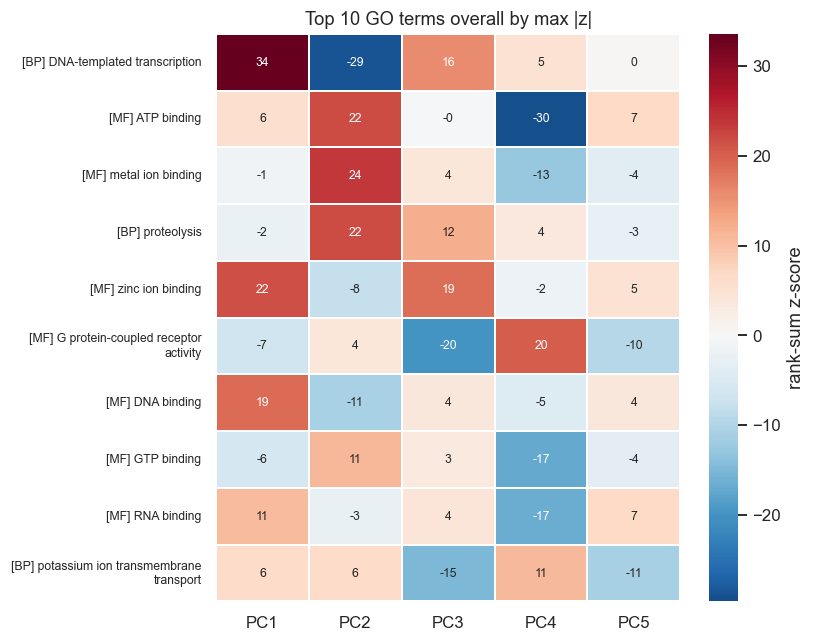

In [45]:
# Fig 4a (v3): top 10 GO terms overall by max |z| across PC1-PC5 (not one slot
# per PC -- a single global ranking), with the same similarity backfill as the
# other two versions: skip a candidate if it overlaps an already-kept term by
# more than SIMILARITY_THRESHOLD (overlap coefficient), and keep moving down
# the max_abs_z ranking until N_TOP terms are kept.
N_TOP = 10
go_geneset = {go_id: set(members) for aspect in GO_ASPECTS for go_id, members in GENESETS_ALL[aspect].items()}
SIMILARITY_THRESHOLD = 0.5
def overlap_coefficient(a, b):
    return len(a & b) / min(len(a), len(b))

def find_blocker(go_id, kept_ids):
    for k in kept_ids:
        sim = overlap_coefficient(go_geneset[go_id], go_geneset[k])
        if sim > SIMILARITY_THRESHOLD:
            return k, f"{sim:.0%} gene-set overlap"
    return None, None

ranked_overall = fast_gene_long.sort_values("max_abs_z", ascending=False).reset_index(drop=True)

kept_ids, kept_rows = [], []
for _, row in ranked_overall.iterrows():
    if len(kept_ids) >= N_TOP:
        break
    blocker, reason = find_blocker(row["go_id"], kept_ids)
    if blocker is not None:
        print(f"skip {row['term_name']!r} ({reason} with kept term {go_term_name[blocker]!r})")
        continue
    kept_ids.append(row["go_id"])
    kept_rows.append(row)

top_overall = pd.DataFrame(kept_rows).sort_values("max_abs_z", ascending=False).reset_index(drop=True)

labels = [textwrap.fill(f"[{r.aspect}] {r.term_name}", WRAP_WIDTH) for r in top_overall.itertuples()]
plot_df = top_overall[PC_NAMES].set_axis(labels, axis=0)

fig, ax = plt.subplots(figsize=(7.5, max(4, 0.6 * len(plot_df))))
sns.heatmap(plot_df, cmap="RdBu_r", center=0, annot=True, fmt=".0f", linewidths=0.3,
            cbar_kws={"label": "rank-sum z-score"}, annot_kws={"size": 8}, ax=ax)
ax.set_title(f"Top {N_TOP} GO terms overall by max |z|")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig4a_top10_overall_zscore.png", dpi=200, bbox_inches="tight")
plt.show()

In [46]:
dna_t_genes = go_annot[go_annot.go_id == "GO:0006351"].ensg.unique()
print(f"GO:0006351 (DNA-templated transcription): {len(dna_t_genes):,} genes")

mech_go = mech_wp[mech_wp.index.get_level_values("gene").isin(dna_t_genes)]
gene_go_avg = mech_go.groupby(level="gene").mean()
pca_go, scores_go, loadings_go = pca_on(gene_go_avg)

print(f"subset gene-level PCA: {gene_go_avg.shape[0]:,} genes, PC1 = {pca_go.explained_variance_ratio_[0]:.1%}")


GO:0006351 (DNA-templated transcription): 2,111 genes
subset gene-level PCA: 1,639 genes, PC1 = 16.6%


### Supplementary: characterizing the GO-term-restricted average correlations

Compare mean correlations of individual GO gene sets compared to rest of genes

In [47]:
# get gene correlation averaged across VSMs 
## already done (after dropping phyloP): gene_avg
# for a GO annotation (later: multiple go-annotations):
## get mean analysis of genes in GO vs out of GO term
#dna_t_genes = go_annot[go_annot.go_id == "GO:0006351"].ensg.unique()
# dna_t_genes
avg_in_set = gene_avg[gene_avg.index.get_level_values("gene").isin(dna_t_genes)].mean()
avg_out_of_set = gene_avg[~(gene_avg.index.get_level_values("gene").isin(dna_t_genes))].mean()

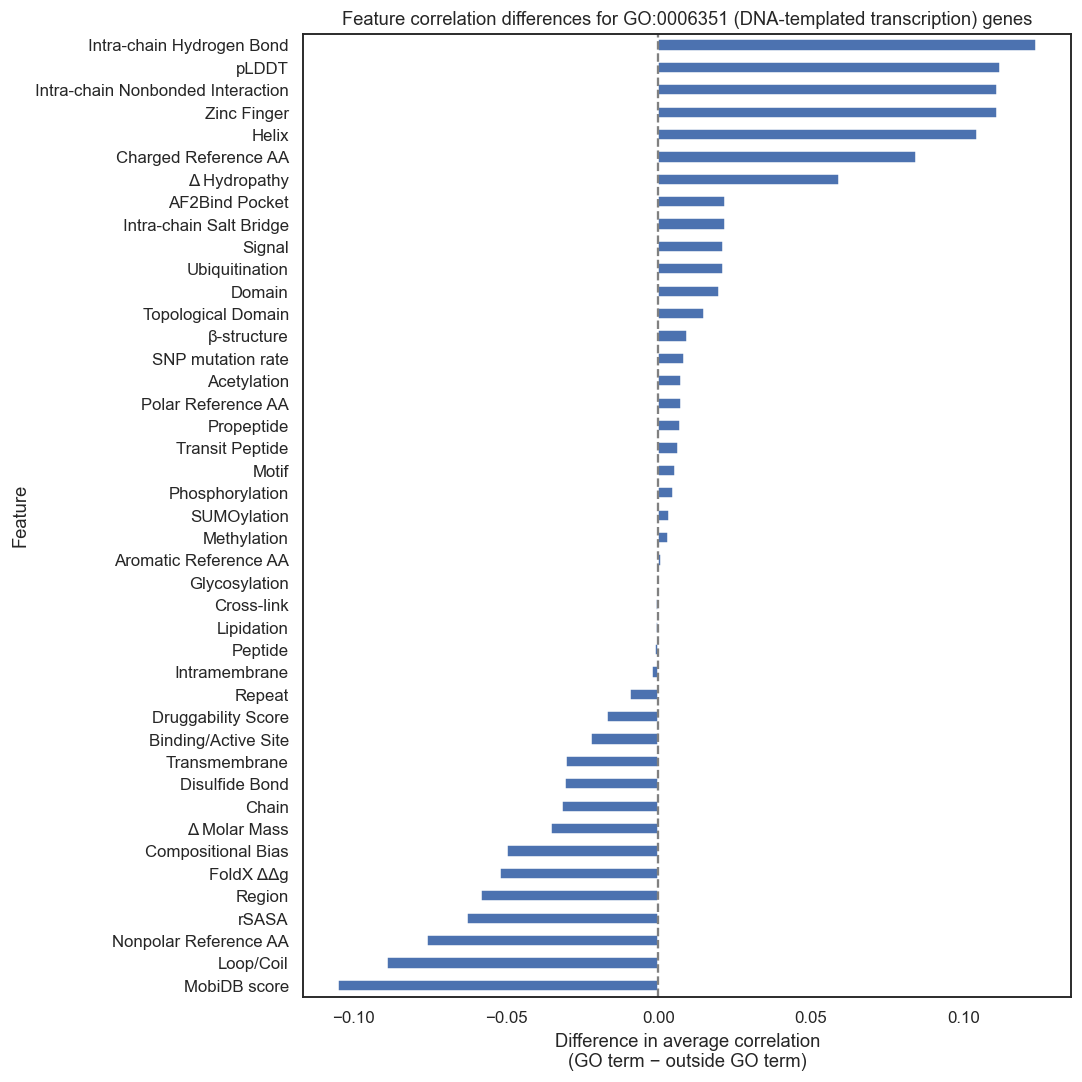

In [48]:
# some comparison of the above
diff = (avg_in_set - avg_out_of_set).sort_values()

fig, ax = plt.subplots(figsize=(10, 10))

diff.plot.barh(ax=ax)

ax.axvline(0, color="gray", linestyle="--")
ax.set_xlabel("Difference in average correlation\n(GO term − outside GO term)")
ax.set_ylabel("Feature")
ax.set_title("Feature correlation differences for GO:0006351 (DNA-templated transcription) genes")

plt.tight_layout()
plt.savefig(GO_OUTDIR / "avg_corr_dif_GO.png", dpi=200, bbox_inches="tight")
plt.show()

### Supplementary: characterizing the GO-term-restricted PCA

The same mechanism-correlation and PC-loading views used in §1-2 for the whole genome, rebuilt on just the case-study gene set, before comparing it back to the genome-wide landscape below.

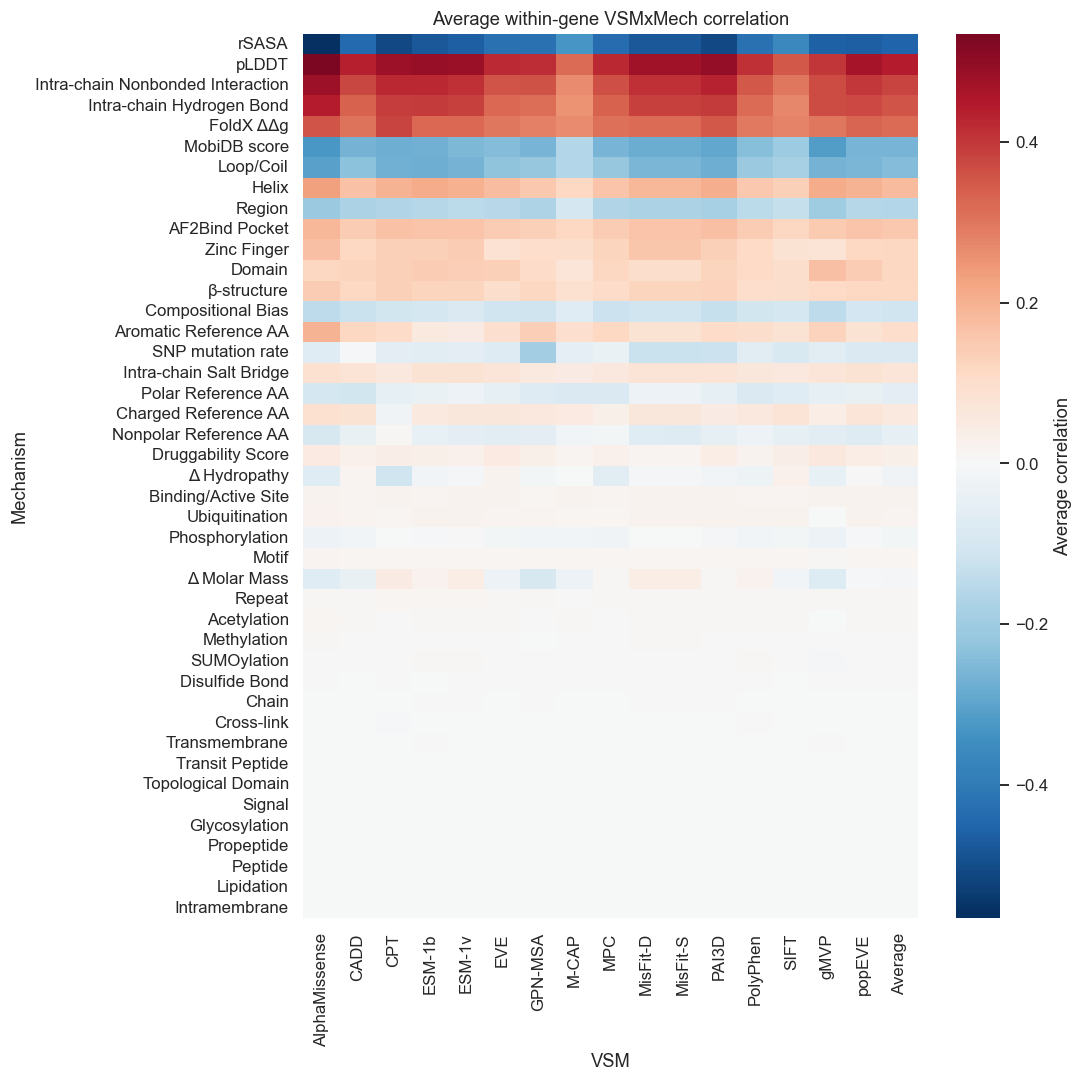

In [49]:
# let's look at the average correlations
mech_go_avg = mech_go.groupby(level="vsm").mean().T
# Add average across VSMs
mech_go_avg["Average"] = mech_go_avg.mean(axis=1)
# Sort mechanisms by average correlation
#mech_avg = mech_avg.sort_values("Average", ascending=False)
mech_go_avg = mech_go_avg.loc[
    mech_go_avg["Average"].abs().sort_values(ascending=False).index
]


plt.figure(figsize=(10, 10))

#sns.clustermap(
ax = sns.heatmap(
    mech_go_avg,
    cmap="RdBu_r",
    center=0,
    annot=False,
    #fmt=".2f", 
    #col_cluster=False
)

ax.collections[0].colorbar.set_label("Average correlation")
plt.xlabel("VSM")
plt.ylabel("Mechanism")
plt.title("Average within-gene VSMxMech correlation")
plt.tight_layout()
plt.show()

#plt.savefig(f'{OUTDIR}/average_correlation.png')

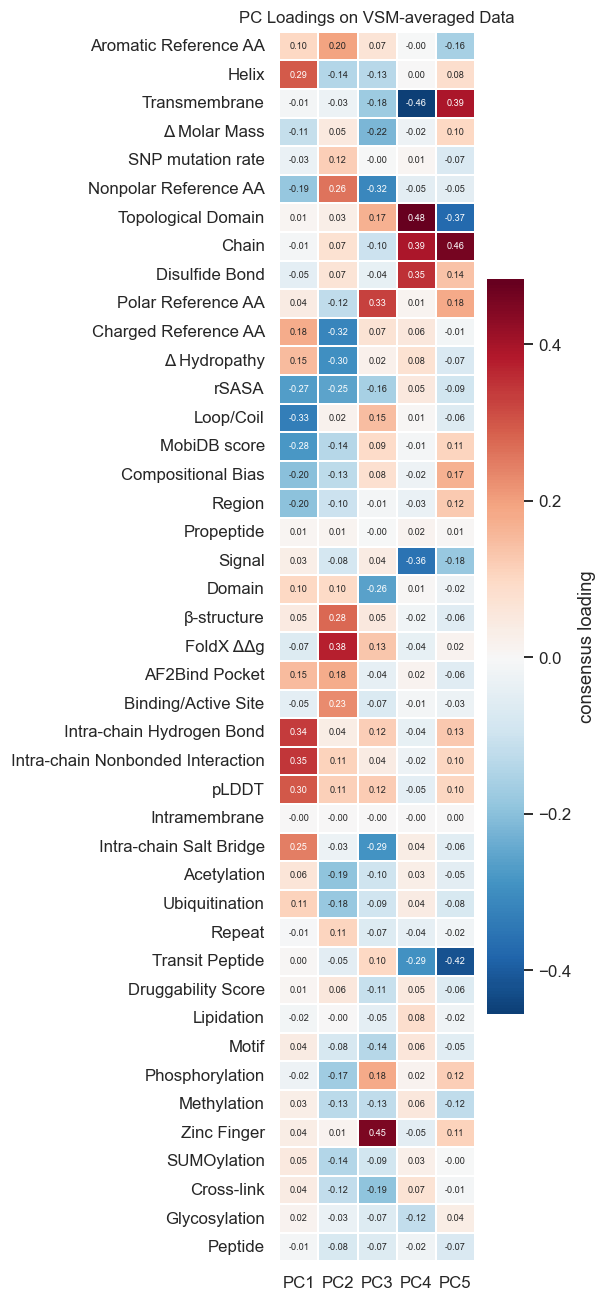

In [50]:
# all PCs in one panel, shared scale.
ROW_ORDER = dendrogram_order(consensus, axis=0)
fig, ax = plt.subplots(figsize=(5.5, 12))
sns.heatmap(loadings_go.loc[ROW_ORDER][['PC1', 'PC2', 'PC3', 'PC4', 'PC5']], cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6}, linewidths=0.3, ax=ax,
            cbar_kws={"label": "consensus loading"})
ax.set_title("PC Loadings on VSM-averaged Data", fontsize=11)
ax.set(xlabel="", ylabel="")
fig.tight_layout()
os.makedirs(f'{GO_OUTDIR}/gene_level', exist_ok=True)
fig.savefig(GO_OUTDIR / "gene_level/pc_loading_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

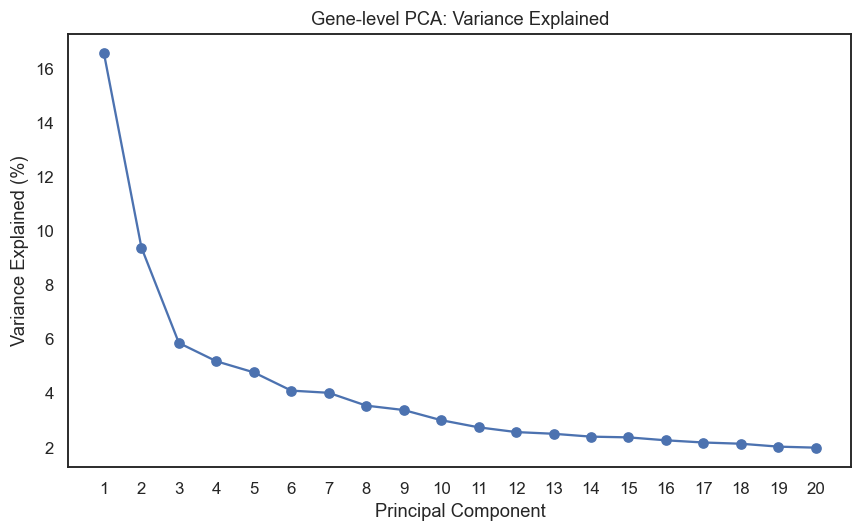

In [51]:
# variance explained
n_pcs = 20

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, n_pcs + 1),
    pca_go.explained_variance_ratio_[:n_pcs] * 100,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Variance Explained (%)")
plt.title("Gene-level PCA: Variance Explained")

plt.xticks(range(1, n_pcs + 1))
plt.tight_layout()
plt.savefig(GO_OUTDIR / "gene_level/variance_explained.png", dpi=200, bbox_inches="tight")

plt.show()

In [52]:
# let's look at the average correlations
mech_avg_g_go = mech_go.groupby(level="gene").mean()
palette = {
    "positive_avg_corr": "tab:blue",
    "no_avg_corr": "tab:gray",
    "negative_avg_corr": "tab:red",
}

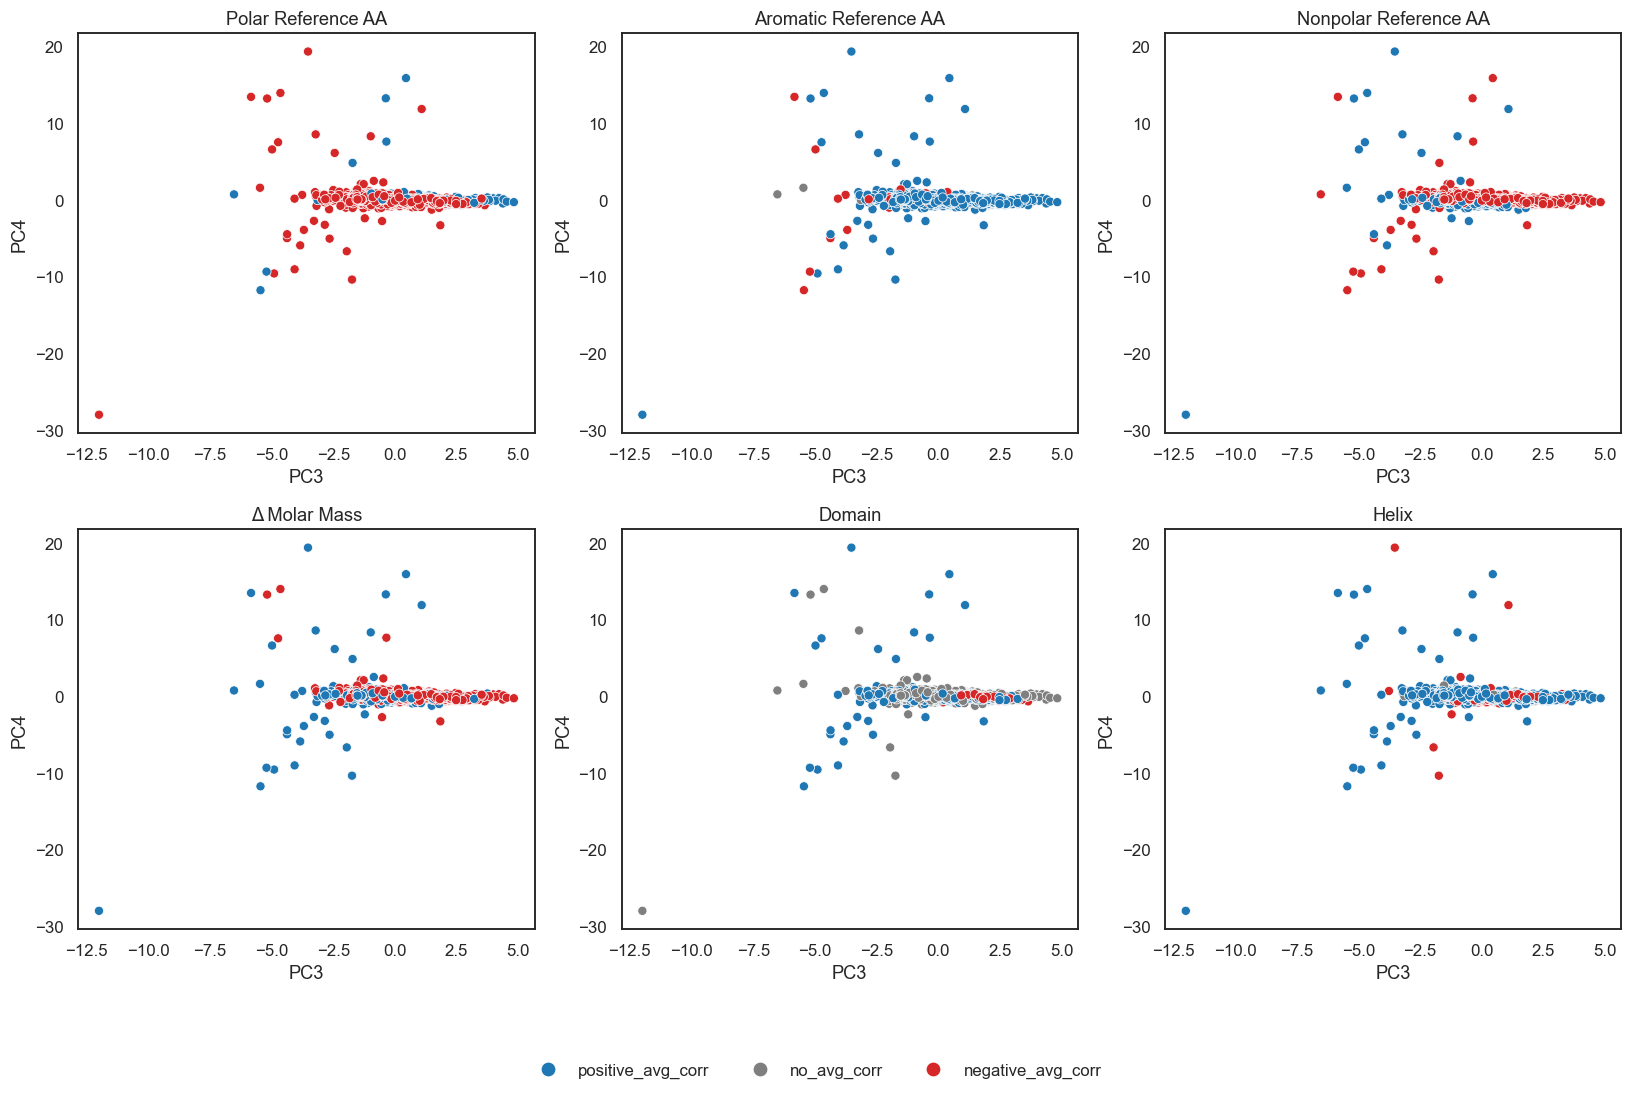

In [53]:
# plotting the PC space: PC3 vs PC4
pc_df = pd.DataFrame(
    scores_go[:, [2, 3]],
    columns=["PC3", "PC4"],
    index=gene_go_avg.index
).reset_index()

# add average correlations
pc_df_mech_corr = pc_df.merge(
    mech_avg_g_go,
    left_on="gene",
    right_index=True,
    how="left"
)

pc_df_mech_corr[MECHS] = pc_df_mech_corr[MECHS].apply(
    lambda col: np.select(
        [col > 0, col == 0, col < 0],
        ["positive_avg_corr", "no_avg_corr", "negative_avg_corr"],
        default="no_avg_corr",
    )
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# hue_cols = [
#     "transmembrane",
#     "ss_undefined",
#     "delta_hydropathy",
#     "delta_molar_mass",
#     "Nonpolar_Neutral",
#     "Polar_Neutral",
# ]

hue_cols = [
    "Polar Reference AA",
    "Aromatic Reference AA",
    "Nonpolar Reference AA",
    "Δ Molar Mass",
    "Domain",
    "Helix",
    "Transmembrane",
] # intra_chain_salt_bridge

hue_order = [
    "positive_avg_corr",
    "no_avg_corr",
    "negative_avg_corr"
]

for ax, hue_col in zip(axes.flat, hue_cols):
    sns.scatterplot(
        data=pc_df_mech_corr,
        x="PC3",
        y="PC4",
        hue=hue_col,
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        legend=False
    )
    ax.set_title(hue_col)

# Create legend handles manually
handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=palette[label],
        markeredgecolor=palette[label],
        markersize=8,
        label=label
    )
    for label in hue_order
]

# One shared legend
fig.legend(
    handles=handles,
    labels=hue_order,
    loc="lower center",
    ncol=3,
    frameon=False,
    title=None
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    GO_OUTDIR / "gene_level/PCA3_PCA4_w_corr.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

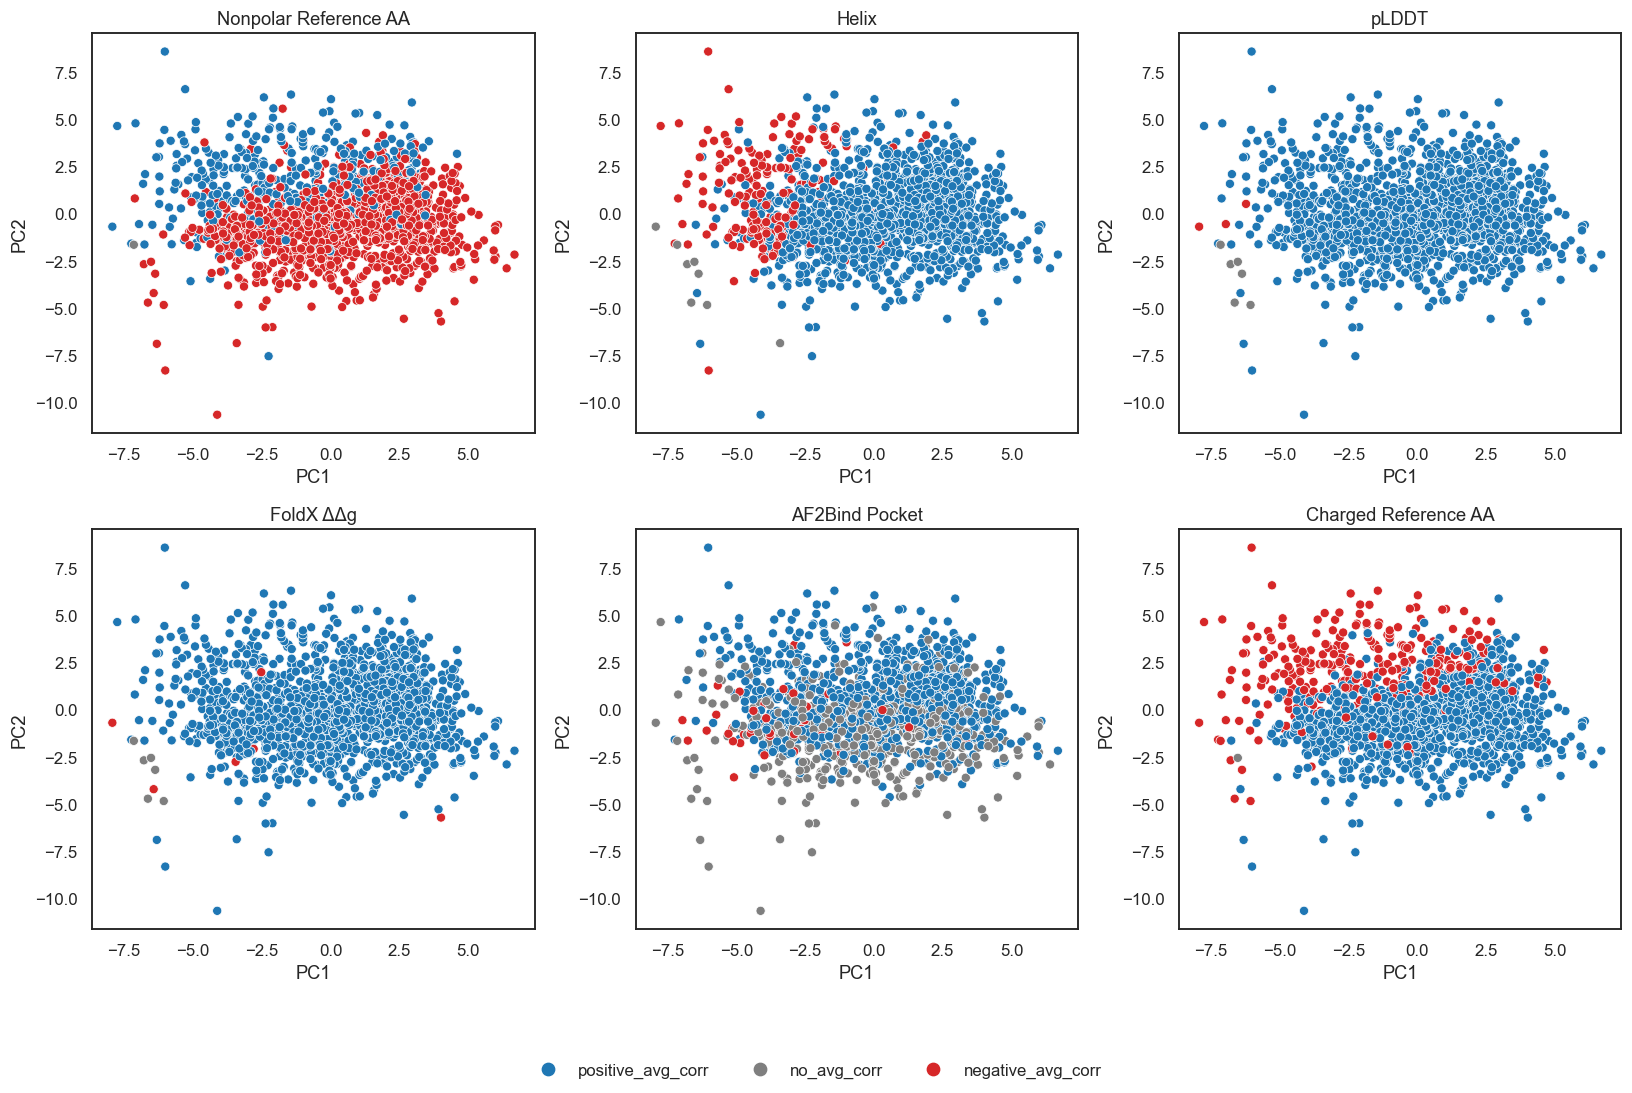

In [54]:
# plotting the PC space: PC1 vs PC2
pc_df = pd.DataFrame(
    scores_go[:, [0, 1]],
    columns=["PC1", "PC2"],
    index=gene_go_avg.index
).reset_index()

# add average correlations
pc_df_mech_corr = pc_df.merge(
    mech_avg_g_go,
    left_on="gene",
    right_index=True,
    how="left"
)

pc_df_mech_corr[MECHS] = pc_df_mech_corr[MECHS].apply(
    lambda col: np.select(
        [col > 0, col == 0, col < 0],
        ["positive_avg_corr", "no_avg_corr", "negative_avg_corr"],
        default="no_avg_corr",
    )
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# hue_cols = [
#     "plddt",
#     "foldx_ddg",
#     "rsasa",
#     "af2bind_pocket",
#     "intra_chain_nonbonded_interaction",
#     "Charged",
# ]

hue_cols = [
    "Nonpolar Reference AA",
    "Helix",
    "pLDDT",
    "FoldX ΔΔg",
    "AF2Bind Pocket",
    "Charged Reference AA",
]

hue_order = [
    "positive_avg_corr",
    "no_avg_corr",
    "negative_avg_corr"
]

for ax, hue_col in zip(axes.flat, hue_cols):
    sns.scatterplot(
        data=pc_df_mech_corr,
        x="PC1",
        y="PC2",
        hue=hue_col,
        hue_order=hue_order,
        palette=palette,
        ax=ax,
        legend=False
    )
    ax.set_title(hue_col)

# Create legend handles manually
handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=palette[label],
        markeredgecolor=palette[label],
        markersize=8,
        label=label
    )
    for label in hue_order
]

# One shared legend
fig.legend(
    handles=handles,
    labels=hue_order,
    loc="lower center",
    ncol=3,
    frameon=False,
    title=None
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

fig.savefig(
    GO_OUTDIR / "gene_level/PCA1_PCA2_w_corr.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

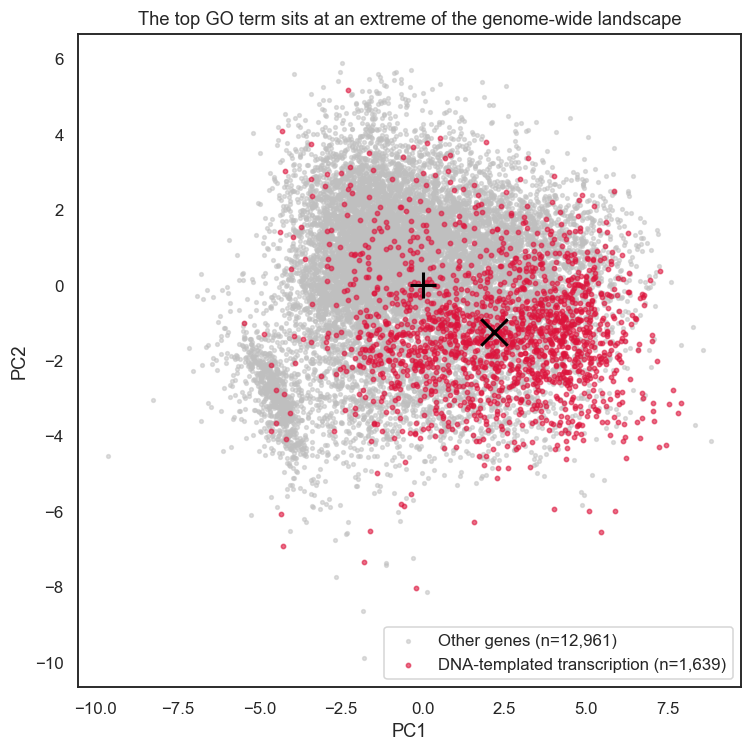

In [55]:
# Fig 4b: does the top GO term sit at an extreme of the genome-wide landscape?
all_pc12 = pd.DataFrame(scores_g[:, :2], columns=["PC1", "PC2"], index=gene_avg.index)
is_term = all_pc12.index.isin(dna_t_genes)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(all_pc12.loc[~is_term, "PC1"], all_pc12.loc[~is_term, "PC2"],
           s=6, color="0.75", alpha=0.5, label=f"Other genes (n={(~is_term).sum():,})")
ax.scatter(all_pc12.loc[is_term, "PC1"], all_pc12.loc[is_term, "PC2"],
           s=8, color="crimson", alpha=0.6, label=f"DNA-templated transcription (n={is_term.sum():,})")
ax.scatter(*all_pc12.mean(), marker="+", s=300, color="black", linewidth=2)
ax.scatter(*all_pc12.loc[is_term].mean(), marker="x", s=300, color="black", linewidth=2)
ax.set(xlabel="PC1", ylabel="PC2")
ax.set_title("The top GO term sits at an extreme of the genome-wide landscape")
ax.legend()
fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig4b_go_term_in_full_pc_space.png", dpi=200, bbox_inches="tight")
plt.show()


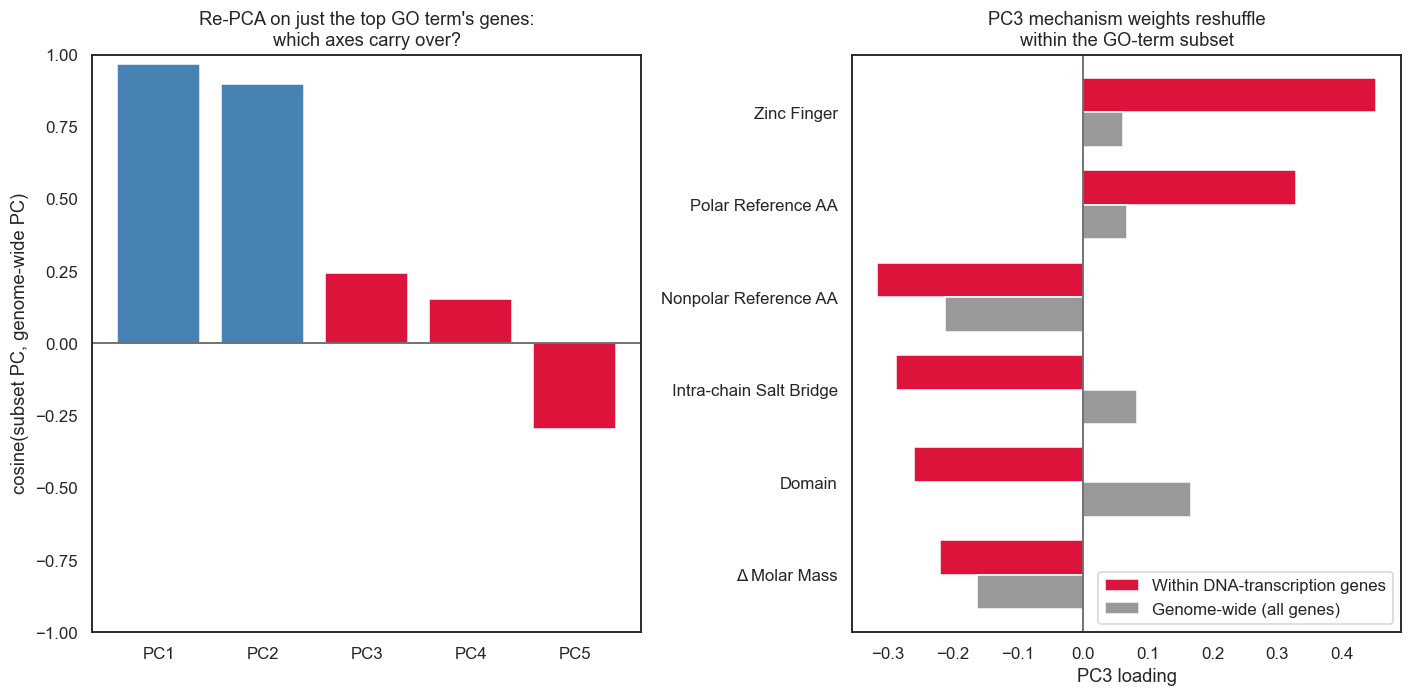

PC1    0.968
PC2    0.898
PC3    0.243
PC4    0.154
PC5   -0.296
dtype: float64


In [56]:
# Fig 4c: re-PCA on just this GO term's genes -- do the top axes carry over?
cos_by_pc = pd.Series({pc: cosine(loadings_go[pc], loadings_g[pc]) for pc in PC_NAMES})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6.5))

colors = ["steelblue" if abs(v) > 0.7 else "crimson" for v in cos_by_pc]
ax1.bar(cos_by_pc.index, cos_by_pc.values, color=colors)
ax1.axhline(0, color="0.3", lw=1)
ax1.set(ylabel="cosine(subset PC, genome-wide PC)", ylim=(-1, 1))
ax1.set_title("Re-PCA on just the top GO term's genes:\nwhich axes carry over?")

subset_pc3_top = loadings_go["PC3"].abs().sort_values(ascending=False).head(6).index
compare = pd.DataFrame({
    "Within DNA-transcription genes": loadings_go.loc[subset_pc3_top, "PC3"],
    "Genome-wide (all genes)": loadings_g.loc[subset_pc3_top, "PC3"],
})
compare.plot.barh(ax=ax2, color=["crimson", "0.6"], width=0.75)
ax2.axvline(0, color="0.3", lw=1)
ax2.invert_yaxis()
ax2.set(xlabel="PC3 loading", ylabel="")
ax2.set_title("PC3 mechanism weights reshuffle\nwithin the GO-term subset")

fig.tight_layout()
fig.savefig(GO_OUTDIR / "fig4c_subset_pca_reorganization.png", dpi=200, bbox_inches="tight")
plt.show()

print(cos_by_pc.round(3))


In [57]:
# Key numbers referenced in the takeaways below (computed, not hardcoded)
outlier_final_cosines = match_quality.loc[outlier]
print("Summary of key statistics")
print("=" * 60)
print(f"Reference VSM: {REFERENCE}")
print(f"Weakest-matching VSM: {outlier} (mean |cosine| = {match_quality.mean(axis=1)[outlier]:.2f})")
print(f"  {outlier} cosine to reference, PC1-PC5: " + ", ".join(f"{v:.2f}" for v in outlier_final_cosines))
print()
print("Gene-level PCA variance explained (PhyloP excluded):")
for i, pc in enumerate(PC_NAMES):
    print(f"  {pc}: {pca_g.explained_variance_ratio_[i]:.1%}")
print()
print(f"GO terms tested (BP+MF, >={FAST_MIN_GENES} genes): {len(fast_gene_long)}")
print(f"  exceeding |z|=2 on some PC: {pct2:.0f}%")
print(f"  exceeding |z|=3 on some PC: {pct3:.0f}%")
print(f"PC1 vs PC2 GO enrichment correlation: r={r:+.2f}")
print()
print(f"Case study: GO:0006351 (DNA-templated transcription), {len(dna_t_genes):,} genes")
print("  cosine(subset PC, genome-wide PC) by PC: " + ", ".join(f"{pc}={v:+.2f}" for pc, v in cos_by_pc.items()))


Summary of key statistics
Reference VSM: AlphaMissense
Weakest-matching VSM: PhyloP (mean |cosine| = 0.78)
  PhyloP cosine to reference, PC1-PC5: 0.91, 0.90, 0.82, 0.65, 0.60

Gene-level PCA variance explained (PhyloP excluded):
  PC1: 16.8%
  PC2: 9.4%
  PC3: 6.8%
  PC4: 5.9%
  PC5: 3.8%

GO terms tested (BP+MF, >=100 genes): 150
  exceeding |z|=2 on some PC: 100%
  exceeding |z|=3 on some PC: 95%
PC1 vs PC2 GO enrichment correlation: r=-0.78

Case study: GO:0006351 (DNA-templated transcription), 2,111 genes
  cosine(subset PC, genome-wide PC) by PC: PC1=+0.97, PC2=+0.90, PC3=+0.24, PC4=+0.15, PC5=-0.30


## Takeaways

- Independently-trained VSMs agree closely on the top PCA axes over gene-level mechanism correlations; the weakest-matching VSM identified in §1 (see the printed summary above) is the natural PhyloP-like outlier — a pure conservation signal with no protein-structure information — and it diverges specifically on the later, lower-variance PCs.
- The consensus PCs (with that outlier excluded) map onto interpretable, largely independent mechanistic themes (§2): each PC's top mechanisms tell a different structural/biochemical story, and different PC pairs separate genes along visibly different biology.
- These axes are pervasively supported by GO enrichment, not statistical artifacts (§3) — the large majority of substantial GO terms reach a strong effect size on at least one PC, and PC1 vs. PC2 enrichment traces out a real, strongly anticorrelated contrast between two different functional programs.
- The case study (§4) shows the top-ranked GO term sits at a genuine extreme of the genome-wide PC1xPC2 landscape, and that its top two axes are stable even when PCA is restricted to just that gene set — while the lower PCs are not, and pick up new, subset-specific structure once the dominant signal is factored out.